# Segmentación Inteligente de Clientes — Swarovski Ecuador (2023–2025)
## Proyecto de Grado | Maestría en Inteligencia Artificial Aplicada
**Autores:** Jhon Sánchez | Vinicio Betancourt  
**Versión:** 5.0 — Código Final  

---
### Cambios v5.0 vs v4.0
- **Producto:** Normalización por fila en lugar de MinMaxScaler global
- **Ciclo de Vida:** `INDICE_FRESCURA` renombrado a `INDICE_ABANDONO` (semántica correcta)
- **XAI Valor:** Centroides calculados con `VENTA_TOTAL_REAL` (no winsorizada)

---
### 🗂️ Instrucciones de uso
1. Ejecuta **BLOQUE 1** primero (imports y constantes)
2. Ejecuta los bloques **en orden** de arriba hacia abajo
3. **FASE 1** (óptimo estadístico): todos los `K_FINAL_xxx = None` en BLOQUE 1
4. **FASE 2** (óptimo estratégico): cambia en BLOQUE 1:
   - `K_FINAL_RFM = 4`
   - `K_FINAL_PRODUCTO = 3`
   - `K_FINAL_CICLO = 3`
   - `K_FINAL_VALOR = 4`
5. En BLOQUE 10 usa el **botón 📥** para descargar el Excel final

---

In [71]:
# -*- coding: utf-8 -*-
"""Swarovski_Segmentacion_v4_Final.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1s3E3ByXC55kulE9vovVKEpvw-R1GkTIP

# Segmentación Inteligente de Clientes — Swarovski Ecuador (2023–2025)
## Proyecto de Grado | Maestría en Inteligencia Artificial Aplicada
**Autores:** Jhon Sánchez | Vinicio Betancourt
**Versión:** 4.0 — Código Final con FASE 1 / FASE 2

---
### 🗂️ Instrucciones de uso
1. Ejecuta **BLOQUE 1** primero (imports y constantes)
2. Ejecuta los bloques **en orden** de arriba hacia abajo
3. **FASE 1** (óptimo estadístico): todos los `K_FINAL_xxx = None` en BLOQUE 1
4. **FASE 2** (óptimo estratégico): cambia en BLOQUE 1:
   - `K_FINAL_RFM = 4`
   - `K_FINAL_PRODUCTO = 3`
   - `K_FINAL_CICLO = 3`
   - `K_FINAL_VALOR = 4`
5. En BLOQUE 10 usa el **botón 📥** para descargar el Excel final

---
"""

# -*- coding: utf-8 -*-
"""Swarovski_Segmentacion_v3_Final.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1yGQclOOdXikTNCwg_hK-WcWJWMr3a6iM

# Segmentación Inteligente de Clientes — Swarovski Ecuador (2023–2025)
## Proyecto de Grado | Maestría en Inteligencia Artificial Aplicada
**Autores:** Jhon Sánchez | Vinicio Betancourt
**Versión:** 3.0 — Código Final

---
### 🗂️ Instrucciones de uso
1. Ejecuta **BLOQUE 1** primero (imports y constantes)
2. Ejecuta los bloques **en orden** de arriba hacia abajo
3. Usa los **▶ desplegables** para navegar entre bloques
4. En BLOQUE 10 usa el **botón 📥** para descargar el Excel final

---
"""

# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  PROYECTO DE GRADO — MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA           ║
║  Segmentación Inteligente de Clientes | Swarovski Ecuador (2023–2025)       ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Autores : Jhon Sánchez | Vinicio Betancourt                                ║
║  Versión : 5.0 — Código Final                                               ║
║  Entorno : Google Colab + Google Drive                                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

FLUJO DEL PIPELINE:
  1. Ingreso de data anonimizada
  2. Preprocesamiento + construcción de 4 datasets por cliente
  3. Por cada dimensión: auto-K + auto-eps + benchmark 4 algoritmos + mejor modelo
  4. Segmentación final con etiquetas automáticas por centroide
  5. Entrega de resultados como herramienta de decisión estratégica

ESTRUCTURA (desplegables ▶ de Colab):
  BLOQUE 0  Gobernanza de datos y privacidad
  BLOQUE 1  Imports y constantes globales
  BLOQUE 2  Ingesta de datos y EDA
  BLOQUE 3  Preprocesamiento y construcción de datasets por cliente
  BLOQUE 4  Segmentación RFM
  BLOQUE 5  Segmentación por Afinidad de Producto
  BLOQUE 6  Segmentación por Ciclo de Vida
  BLOQUE 7  Segmentación por Valor / Margen
  BLOQUE 8  Validación y pruebas de sensibilidad
  BLOQUE 9  Interpretabilidad (XAI) y análisis ético
  BLOQUE 10 Consolidación, panel interactivo y exportación
"""


# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 🔒 BLOQUE 0 — GOBERNANZA DE DATOS Y PRIVACIDAD { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("🔒 BLOQUE 0 — Gobernanza documentada. Iniciando pipeline sobre datos anonimizados.")

🔒 BLOQUE 0 — Gobernanza documentada. Iniciando pipeline sobre datos anonimizados.


In [72]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 📦 BLOQUE 1 — IMPORTS Y CONSTANTES GLOBALES { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import warnings
import numpy as np
import pandas as pd
from datetime import datetime
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import drive, files

# ── Constantes globales ───────────────────────────────────────────────────────
RANDOM_STATE  = 42          # Semilla: garantiza reproducibilidad total
N_INIT        = 10          # Inicializaciones K-Means (estabilidad ante varianza)
PERC_LOW      = 1           # Percentil inferior — clipping de outliers
PERC_HIGH     = 99          # Percentil superior — clipping de outliers
DBSCAN_MIN_S  = 5           # Muestras mínimas para núcleo en DBSCAN
K_MIN         = 2           # Inicio del rango de búsqueda de K
K_MAX         = 11          # Fin del rango de búsqueda de K (K∈[2,11])
WINSOR_VALOR  = 95          # Percentil de winsorización para VENTA_TOTAL en clustering

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE K POR DIMENSIÓN
# ══════════════════════════════════════════════════════════════════════════════
#
# FASE 1 — ÓPTIMO ESTADÍSTICO (dejar en None):
#   El algoritmo determina automáticamente el K con mayor Silhouette Score.
#   Resultado documentado: K=2 en RFM, Ciclo y Valor. Válido estadísticamente.
#   Ejecutar primero para documentar el baseline algorítmico en la tesis.
#
# FASE 2 — ÓPTIMO ESTRATÉGICO (asignar K de negocio):
#   Decisión metodológica documentada: el modelo estadísticamente óptimo
#   no siempre coincide con el estratégicamente útil (Kasem et al., 2024).
#   K=2 genera segmentos demasiado polarizados para diseñar estrategias
#   de marketing diferenciadas. Se fuerza K mayor con justificación de negocio.
#
#   Decisión por dimensión (métricas con normalización por fila v5.0):
#     RFM=4      → 4 estrategias: VIP · Fieles en Riesgo · Nuevos · Inactivos
#                  Silhouette K=4: 0.5915 (rango aceptable >0.5)
#     Producto=3 → K=3 con K-Means y normalización por fila
#                  Silhouette: 0.8420 — ganador estadístico K-Means
#     Ciclo=3    → K=3 añade segmento "Fugaces" crítico para retención
#                  Silhouette: 0.9172 — prácticamente sin sacrificio vs K=2
#     Valor=4    → 4 niveles financieros tras Winsorización P95
#                  Silhouette K-Means K=4: 0.5532 (rango moderado aceptable)
#
# INSTRUCCIÓN:
#   FASE 1 → cambiar todos los valores a None y correr el notebook completo
#   FASE 2 → usar los valores asignados abajo y correr el notebook completo
# ──────────────────────────────────────────────────────────────────────────────
K_FINAL_RFM      = 4    # FASE 1: None  |  FASE 2: 4
K_FINAL_PRODUCTO = 3    # FASE 1: None  |  FASE 2: 3
K_FINAL_CICLO    = 3    # FASE 1: None  |  FASE 2: 3
K_FINAL_VALOR    = 4    # FASE 1: None  |  FASE 2: 4

# ── Rutas del proyecto ────────────────────────────────────────────────────────
PATH_DRIVE   = '/content/drive/MyDrive/Proyecto_Swarovski'
FILE_DATASET = 'Swarovski_Dataset_Limpio_Anonimizado.csv'
FILE_FINAL   = 'SEGMENTACION_MULTIVARIABLE_SWAROVSKI_FINAL.xlsx'

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')
PALETA = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD', '#8C564B']

print("✅ BLOQUE 1 — Imports y constantes listos.")
print(f"   random_state={RANDOM_STATE} | n_init={N_INIT} | K∈[{K_MIN},{K_MAX}] | clipping P{PERC_LOW}-P{PERC_HIGH}")
print(f"   FASE activa: {'2 — Óptimo estratégico' if K_FINAL_RFM is not None else '1 — Óptimo estadístico'}")
print(f"   K configurados: RFM={K_FINAL_RFM} | Producto={K_FINAL_PRODUCTO} | Ciclo={K_FINAL_CICLO} | Valor={K_FINAL_VALOR}")

✅ BLOQUE 1 — Imports y constantes listos.
   random_state=42 | n_init=10 | K∈[2,11] | clipping P1-P99
   FASE activa: 2 — Óptimo estratégico
   K configurados: RFM=4 | Producto=3 | Ciclo=3 | Valor=4


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ✅ Fechas parseadas sin pérdida (35,822 registros)
✅ Dataset cargado | Registros: 35,822 | Variables: 18
   Período   : 2023-01-01 → 2025-12-31
   Clientes  : 17,784 únicos
   Secciones : 11 | Zonas: 13

📋 Calidad del dataset:
   Nulos totales      : 3 (solo TELEFONO y MAIL)
   Duplicados         : 0
   VENTA negativa     : 990 registros (devoluciones)
   VENTA = 0          : 3 registros (transacciones vacías)
   VENTA positiva     : 34,829 registros útiles
   Secciones          : {'COLLAR': 10747, 'ARETES': 10697, 'PULSERA': 5860, 'ANILLO': 5134, 'BOLIGRAFOS': 2017, 'INDETERMINADO': 812, 'RELOJ Y SUS ACCESORIOS': 394, 'FAMILIA 70-80': 98, 'HOME': 37, 'LLAVEROS, MOBILE PHONE Y CHARM': 17, 'PRENDEDORES Y GEMELOS': 9}


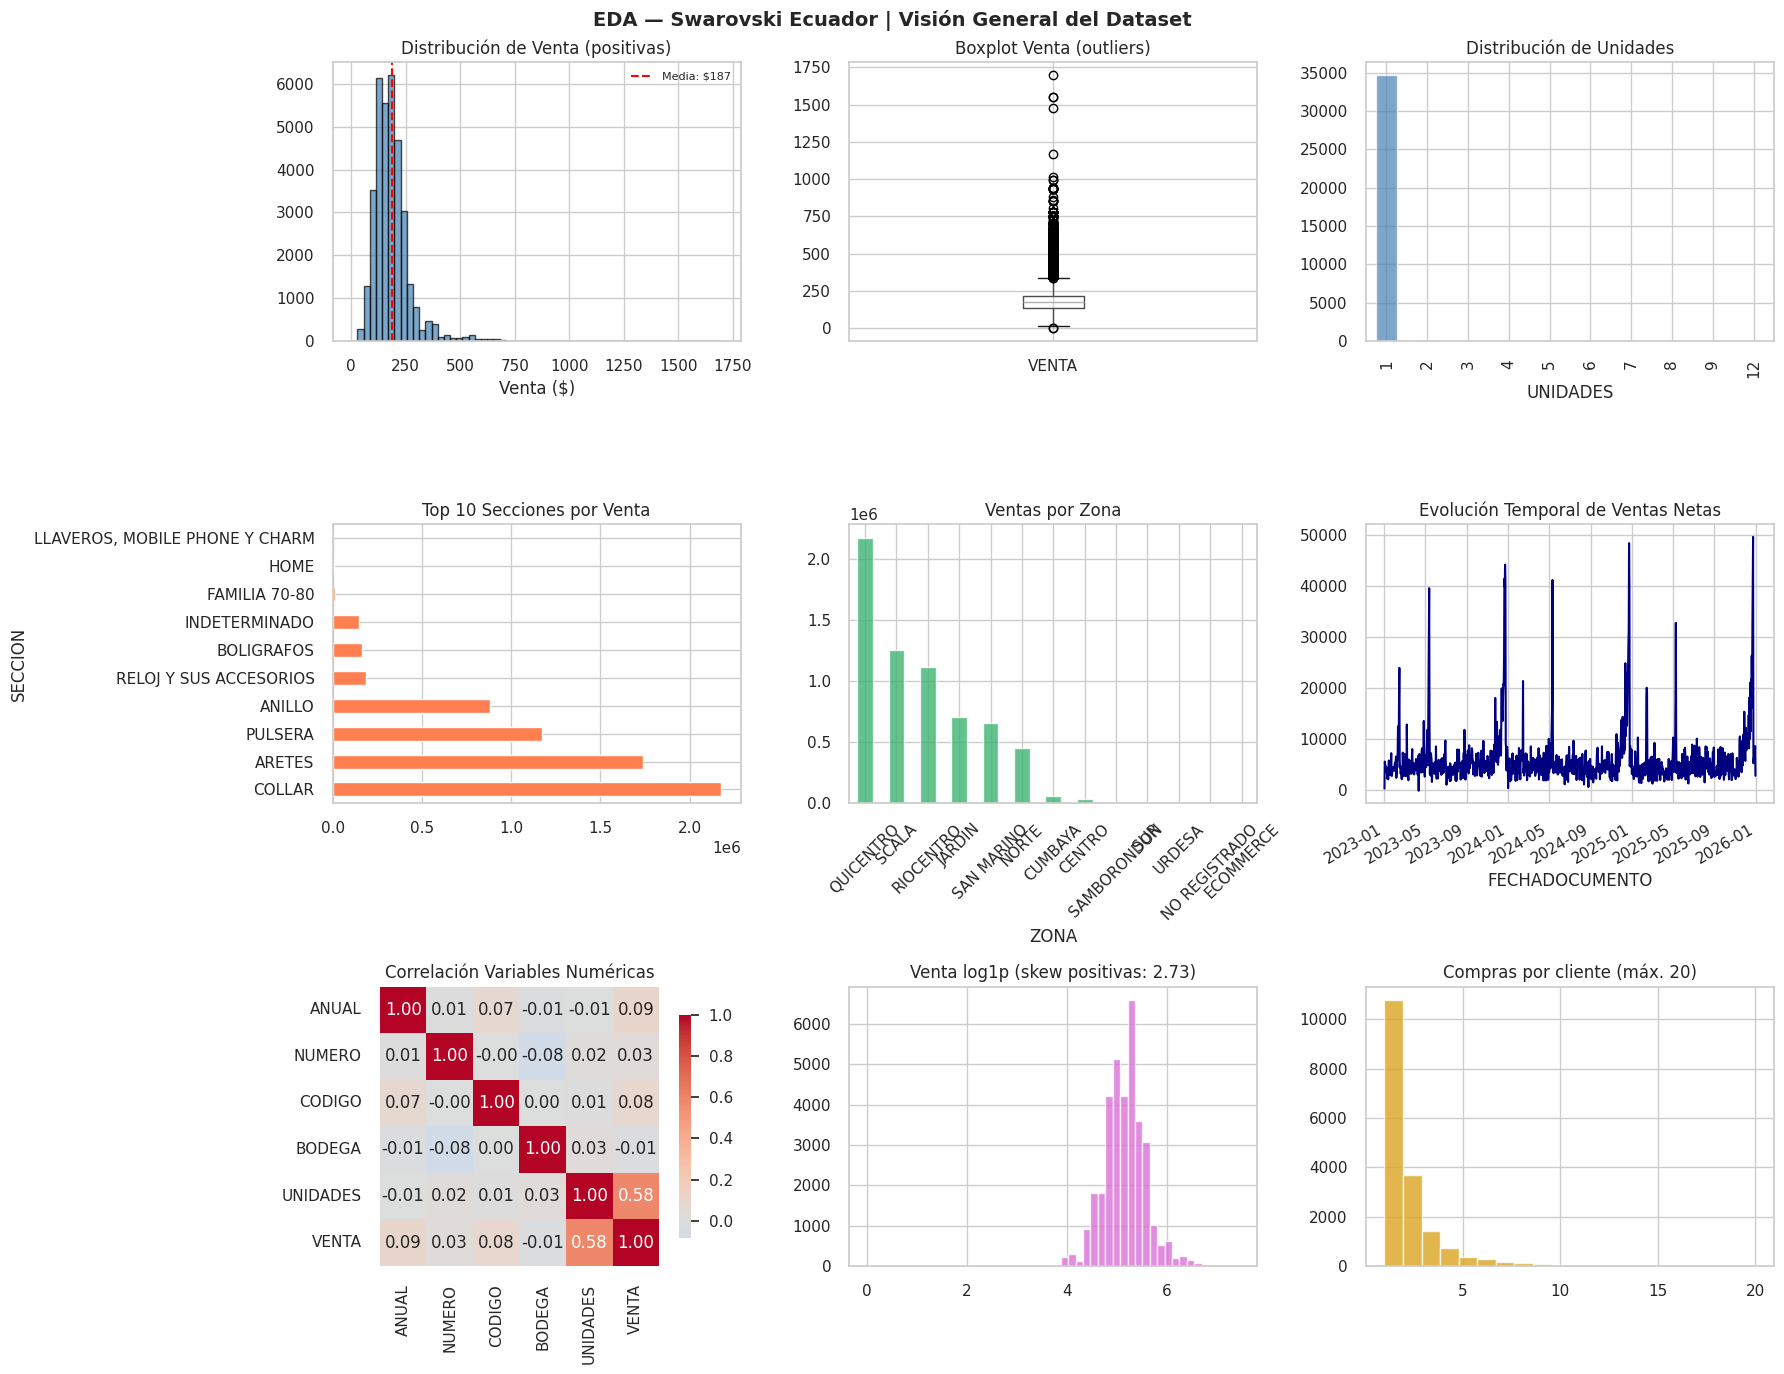

✅ BLOQUE 2 — EDA completado.


In [73]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 📂 BLOQUE 2 — INGESTA DE DATOS Y EDA { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── 2.1 Montaje y carga ───────────────────────────────────────────────────────
drive.mount('/content/drive')

ruta = os.path.join(PATH_DRIVE, FILE_DATASET)
try:
    df = pd.read_csv(ruta)

    # CORRECCIÓN: el formato real del dataset es YYYY-MM-DD (ISO 8601).
    # El parámetro dayfirst=True causaba que 22,763 fechas válidas
    # se convirtieran en NaT, reduciendo el dataset al 36% de los registros.
    # Con format='%Y-%m-%d' se parsean correctamente los 35,822 registros.
    df['FECHADOCUMENTO'] = pd.to_datetime(df['FECHADOCUMENTO'],
                                           format='%Y-%m-%d',
                                           errors='coerce')

    # Verificación post-parseo
    fechas_nulas = df['FECHADOCUMENTO'].isna().sum()
    if fechas_nulas > 0:
        print(f"   ⚠️  {fechas_nulas} fechas no pudieron parsearse — revisar formato CSV")
    else:
        print(f"   ✅ Fechas parseadas sin pérdida ({df.shape[0]:,} registros)")

    print(f"✅ Dataset cargado | Registros: {df.shape[0]:,} | Variables: {df.shape[1]}")
    print(f"   Período   : {df['FECHADOCUMENTO'].min().date()} → {df['FECHADOCUMENTO'].max().date()}")
    print(f"   Clientes  : {df['NOMBRE_CLIENTE'].nunique():,} únicos")
    print(f"   Secciones : {df['SECCION'].nunique()} | Zonas: {df['ZONA'].nunique()}")

except FileNotFoundError:
    raise FileNotFoundError(
        f"❌ No se encontró: {ruta}\n"
        f"   Verifica que la carpeta sea 'Proyecto_Swarovski' y el archivo '{FILE_DATASET}'"
    )

# ── 2.2 Reporte de calidad ────────────────────────────────────────────────────
print(f"\n📋 Calidad del dataset:")
print(f"   Nulos totales      : {df.isnull().sum().sum()} (solo TELEFONO y MAIL)")
print(f"   Duplicados         : {df.duplicated().sum()}")
print(f"   VENTA negativa     : {(df['VENTA'] < 0).sum()} registros (devoluciones)")
print(f"   VENTA = 0          : {(df['VENTA'] == 0).sum()} registros (transacciones vacías)")
print(f"   VENTA positiva     : {(df['VENTA'] > 0).sum():,} registros útiles")
print(f"   Secciones          : {df['SECCION'].value_counts().to_dict()}")

# ── 2.3 EDA — 9 visualizaciones ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('EDA — Swarovski Ecuador | Visión General del Dataset', fontsize=14, fontweight='bold')

# 1: Distribución de Venta (solo positivas para visualización)
df[df['VENTA'] > 0]['VENTA'].hist(bins=60, ax=axes[0,0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df[df['VENTA'] > 0]['VENTA'].mean(), color='red', linestyle='--',
                   label=f"Media: ${df[df['VENTA']>0]['VENTA'].mean():.0f}")
axes[0,0].set_title('Distribución de Venta (positivas)')
axes[0,0].set_xlabel('Venta ($)')
axes[0,0].legend(fontsize=8)

# 2: Boxplot — detección visual de outliers
df[df['VENTA'] > 0].boxplot(column='VENTA', ax=axes[0,1])
axes[0,1].set_title('Boxplot Venta (outliers)')

# 3: Distribución de Unidades (solo positivas)
if 'UNIDADES' in df.columns:
    df[df['UNIDADES'] > 0]['UNIDADES'].value_counts().sort_index().head(15).plot(
        kind='bar', ax=axes[0,2], color='steelblue', alpha=0.7)
    axes[0,2].set_title('Distribución de Unidades')

# 4: Top 10 secciones por venta total
if 'SECCION' in df.columns:
    df[df['VENTA'] > 0].groupby('SECCION')['VENTA'].sum().sort_values(ascending=False).head(10).plot(
        kind='barh', ax=axes[1,0], color='coral')
    axes[1,0].set_title('Top 10 Secciones por Venta')

# 5: Venta por zona
if 'ZONA' in df.columns:
    df[df['VENTA'] > 0].groupby('ZONA')['VENTA'].sum().sort_values(ascending=False).plot(
        kind='bar', ax=axes[1,1], color='mediumseagreen', alpha=0.8)
    axes[1,1].set_title('Ventas por Zona')
    axes[1,1].tick_params(axis='x', rotation=45)

# 6: Serie temporal de ventas netas (positivas + negativas reflejan la realidad)
df.groupby('FECHADOCUMENTO')['VENTA'].sum().plot(ax=axes[1,2], linewidth=1.5, color='navy')
axes[1,2].set_title('Evolución Temporal de Ventas Netas')

# 7: Correlación numérica
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[2,0], square=True, cbar_kws={"shrink": 0.8})
axes[2,0].set_title('Correlación Variables Numéricas')

# 8: Venta log-transformada (solo positivas)
np.log1p(df[df['VENTA'] > 0]['VENTA']).hist(bins=50, ax=axes[2,1], color='orchid', alpha=0.8)
axes[2,1].set_title(f"Venta log1p (skew positivas: {df[df['VENTA']>0]['VENTA'].skew():.2f})")

# 9: Frecuencia de compras por cliente (transacciones positivas)
df[df['VENTA'] > 0].groupby('NOMBRE_CLIENTE')['VENTA'].count().clip(upper=20).hist(
    bins=20, ax=axes[2,2], color='goldenrod', alpha=0.8)
axes[2,2].set_title('Compras por cliente (máx. 20)')

plt.tight_layout()
plt.show()
print("✅ BLOQUE 2 — EDA completado.")

In [74]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 🔧 BLOQUE 3 — PREPROCESAMIENTO Y CONSTRUCCIÓN DE DATASETS { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("🔧 BLOQUE 3 — PREPROCESAMIENTO")
print("="*70)

# ── 3.1 Limpieza base del dataset transaccional ───────────────────────────────
df_base = df.copy()

# Eliminar duplicados
n_dup = df_base.duplicated().sum()
df_base = df_base.drop_duplicates()

# Eliminar filas con fechas nulas en FECHADOCUMENTO (crucial para RFM)
df_base.dropna(subset=['FECHADOCUMENTO'], inplace=True)

# Imputar nulos
for col in df_base.columns:
    n_nulos = df_base[col].isnull().sum()
    if n_nulos > 0:
        pct = n_nulos / len(df_base)
        if pct < 0.001:
            df_base = df_base.dropna(subset=[col])
        elif df_base[col].dtype in ['int64', 'float64']:
            df_base[col].fillna(df_base[col].median(), inplace=True)
        else:
            df_base[col].fillna('DESCONOCIDO', inplace=True)

# Clipping de VENTA (P1-P99) — reduce efecto de compras corporativas atípicas
lim_inf = df_base['VENTA'].quantile(PERC_LOW / 100)
lim_sup = df_base['VENTA'].quantile(PERC_HIGH / 100)
df_base['VENTA'] = df_base['VENTA'].clip(lower=lim_inf, upper=lim_sup)

# Filtrar ventas negativas o cero (devoluciones distorsionan el perfil de valor)
df_base = df_base[df_base['VENTA'] > 0].copy()

print(f"✅ Limpieza base:")
print(f"   Duplicados eliminados : {n_dup}")
print(f"   Clipping VENTA        : [${lim_inf:.2f}, ${lim_sup:.2f}]")
print(f"   Registros útiles      : {len(df_base):,}")

# ── 3.2 Dataset 1: RFM ────────────────────────────────────────────────────────
# Fecha de corte = día posterior a la última venta registrada
fecha_corte = df_base['FECHADOCUMENTO'].max()

df_rfm = df_base.groupby('NOMBRE_CLIENTE').agg(
    RECENCIA   = ('FECHADOCUMENTO', lambda x: (fecha_corte - x.max()).days),
    FRECUENCIA = ('VENTA', 'count'),
    MONETARIO  = ('VENTA', 'sum')
).reset_index()

# Clipping individual por variable RFM (P99) — suaviza efecto de outliers VIP
for col in ['RECENCIA', 'FRECUENCIA', 'MONETARIO']:
    lim = df_rfm[col].quantile(PERC_HIGH / 100)
    df_rfm[col] = df_rfm[col].clip(upper=lim)

print(f"\n✅ Dataset RFM          : {len(df_rfm):,} clientes")

# ── 3.3 Dataset 2: Afinidad de Producto ──────────────────────────────────────
# Crosstab: filas=clientes, columnas=secciones, valores=frecuencia de compra
df_afinidad_raw = pd.crosstab(df_base['NOMBRE_CLIENTE'], df_base['SECCION'])
cols_seccion = df_afinidad_raw.columns.tolist()

# NORMALIZACIÓN POR FILA (proporción por cliente) ─────────────────────────────
# Divide cada valor por el total de compras de ese cliente.
# Resultado: cada fila suma 1 → % del presupuesto que ese cliente
# destina a cada categoría. Mide ESPECIALIZACIÓN, no volumen.
#
# Por qué NO MinMaxScaler global:
# Normaliza por columna usando el máximo del dataset. Si el máximo
# de ARETES en toda la base es 20, un cliente con 4 compras de aretes
# queda en 0.04 — pierde su especialización relativa.
# Con normalización por fila ese cliente muestra Aretes=0.80 (80% de sus compras).
totales_fila = df_afinidad_raw.sum(axis=1)
df_afinidad_norm = df_afinidad_raw.div(totales_fila, axis=0).fillna(0)

# Ticket medio normalizado 0-1 como proxy del nivel de gasto
ticket_medio = df_base.groupby('NOMBRE_CLIENTE')['VENTA'].mean()
t_min, t_max = ticket_medio.min(), ticket_medio.max()
df_afinidad_norm['TICKET_MEDIO'] = (ticket_medio - t_min) / (t_max - t_min + 1e-9)

df_producto = df_afinidad_norm.reset_index()
X_prod = df_afinidad_norm.values

print(f"✅ Dataset Producto      : {len(df_producto):,} clientes × {df_afinidad_norm.shape[1]} categorías")
print(f"   Secciones analizadas  : {cols_seccion}")
print(f"   Normalización         : por fila — proporción por cliente (preserva especialización)")

# ── 3.4 Dataset 3: Ciclo de Vida ──────────────────────────────────────────────
# Captura en qué etapa de su relación con la marca está cada cliente
df_ciclo = df_base.groupby('NOMBRE_CLIENTE').agg(
    ANTIGUEDAD      = ('FECHADOCUMENTO', lambda x: (fecha_corte - x.min()).days),
    VIDA_ACTIVA     = ('FECHADOCUMENTO', lambda x: (x.max() - x.min()).days),
    COMPRAS_TOTALES = ('VENTA', 'count')
).reset_index()

# ÍNDICE DE ABANDONO: mide qué tan alejado está el cliente de la marca
# relativo a su historia total con la marca.
# Fórmula: (Antigüedad - Vida Activa) / (Antigüedad + 1)
# Interpretación:
#   Valor ALTO (≈1): el cliente estuvo activo poco tiempo y lleva mucho
#                    tiempo sin comprar → alto riesgo de abandono
#   Valor BAJO (≈0): su Vida Activa cubre casi toda su Antigüedad
#                    → sigue comprando activamente, baja probabilidad de fuga
# Nota: renombrado desde INDICE_ABANDONO (nombre contraintuitivo) porque
# un valor alto indica inactividad, no "frescura" en la relación.
df_ciclo['INDICE_ABANDONO'] = (
    (df_ciclo['ANTIGUEDAD'] - df_ciclo['VIDA_ACTIVA']) /
    (df_ciclo['ANTIGUEDAD'] + 1)
)

print(f"✅ Dataset Ciclo de Vida : {len(df_ciclo):,} clientes")

# ── 3.5 Dataset 4: Valor / Margen ─────────────────────────────────────────────
# Captura el potencial económico real de cada cliente
df_valor = df_base.groupby('NOMBRE_CLIENTE').agg(
    VENTA_TOTAL       = ('VENTA', 'sum'),
    TICKET_MAX        = ('VENTA', 'max'),
    VENTA_PROMEDIO    = ('VENTA', 'mean'),
    VOLATILIDAD_GASTO = ('VENTA', 'std'),   # Estabilidad del gasto
    TOTAL_UNIDADES    = ('UNIDADES', 'sum')
).reset_index()

df_valor['VOLATILIDAD_GASTO'].fillna(0, inplace=True)  # Clientes con 1 compra → std=0
df_valor['VALOR_POR_UNIDAD'] = (
    df_valor['VENTA_TOTAL'] / (df_valor['TOTAL_UNIDADES'] + 1)  # Proxy de gama del producto
)

print(f"✅ Dataset Valor/Margen  : {len(df_valor):,} clientes")

print("\n✅ BLOQUE 3 — 4 datasets por cliente listos para segmentación.")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ── FUNCIONES COMPARTIDAS (usadas en BLOQUEs 4–7) ────────────────────────────
# ╚══════════════════════════════════════════════════════════════════════════════╝

def calcular_metricas_tridente(X, labels):
    """
    Calcula el Tridente de Métricas de validación interna.
    Excluye automáticamente el ruido (-1) de DBSCAN antes de medir.
    Retorna NaN si hay menos de 2 clusters válidos.
    """
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    if n_clusters < 2:
        return {'Silhouette ↑': np.nan, 'Davies-Bouldin ↓': np.nan, 'Calinski-Harabasz ↑': np.nan}
    return {
        'Silhouette ↑'        : round(silhouette_score(X[mask], labels[mask]), 4),
        'Davies-Bouldin ↓'    : round(davies_bouldin_score(X[mask], labels[mask]), 4),
        'Calinski-Harabasz ↑' : round(calinski_harabasz_score(X[mask], labels[mask]), 4)
    }


def seleccionar_k_optimo(X, k_fijo=None, titulo=''):
    """
    Determina el K óptimo usando Silhouette Score para K ∈ [K_MIN, K_MAX].
    Genera gráfico doble (Codo + Silhouette).
    Si k_fijo no es None, devuelve ese valor directamente sin búsqueda.
    Retorna: k_optimo (int)
    """
    if k_fijo is not None:
        print(f"   K fijo configurado: {k_fijo} (omitiendo búsqueda automática)")
        return k_fijo

    k_range = range(K_MIN, K_MAX + 1)
    inercias, silhouettes = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
        km.fit(X)
        inercias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_))
        print(f"   K={k:2d}: Inercia={km.inertia_:10.2f}  Silhouette={silhouettes[-1]:.4f}")

    k_sugerido = list(k_range)[np.argmax(silhouettes)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(k_range, inercias, 'bo-', linewidth=2)
    ax1.axvline(k_sugerido, color='red', linestyle=':', alpha=0.7, label=f'K={k_sugerido}')
    ax1.set_title(f'Método del Codo — {titulo}')
    ax1.set_xlabel('K')
    ax1.set_ylabel('Inercia (WCSS)')
    ax1.legend()

    ax2.plot(k_range, silhouettes, 'go-', linewidth=2)
    ax2.axvline(k_sugerido, color='red', linestyle=':', alpha=0.7, label=f'K={k_sugerido}')
    ax2.set_title(f'Silhouette Score — {titulo}')
    ax2.set_xlabel('K')
    ax2.set_ylabel('Silhouette Score')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    print(f"\n   ✨ K sugerido automáticamente: {k_sugerido}")
    return k_sugerido


def sugerir_eps_dbscan(X, titulo=''):
    """
    Sugiere eps para DBSCAN usando el gráfico de distancias al k-ésimo vecino.
    Detecta el 'codo' geométrico de la curva de distancias ordenadas.
    Retorna: eps_sugerido (float)
    """
    nbrs = NearestNeighbors(n_neighbors=DBSCAN_MIN_S).fit(X)
    distancias, _ = nbrs.kneighbors(X)
    dist_sorted = np.sort(distancias[:, -1])[::-1]

    # Detección geométrica del codo
    n = len(dist_sorted)
    p1 = np.array([0, dist_sorted[0]])
    p2 = np.array([n - 1, dist_sorted[-1]])
    dists_linea = [np.abs(np.cross(p2 - p1, p1 - np.array([i, dist_sorted[i]])))/
                   np.linalg.norm(p2 - p1) for i in range(n)]
    idx_codo = np.argmax(dists_linea)
    eps_sugerido = round(float(dist_sorted[idx_codo]), 3)

    plt.figure(figsize=(9, 3.5))
    plt.plot(dist_sorted, linewidth=1.5, color='steelblue')
    plt.axhline(eps_sugerido, color='red', linestyle='--', label=f'eps sugerido: {eps_sugerido}')
    plt.axvline(idx_codo, color='gray', linestyle=':', alpha=0.7)
    plt.title(f'kNN — Selección automática de eps | {titulo}')
    plt.xlabel('Puntos ordenados')
    plt.ylabel(f'Distancia al {DBSCAN_MIN_S}° vecino')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"   ✨ eps sugerido automáticamente: {eps_sugerido}")
    return eps_sugerido


def benchmark_tres_algoritmos(X, k, eps, titulo):
    """
    Compara 3 algoritmos: K-Means, Jerárquico (mejor enlace automático) y DBSCAN.
    El clustering jerárquico prueba Ward y Average internamente y reporta
    solo el ganador como 'Jerárquico (Ward)' o 'Jerárquico (Average)'.
    Selecciona el ganador global por mayor Silhouette Score.
    Retorna: df_benchmark, nombre_ganador, labels_ganador
    """
    resultados = []
    labels_dict = {}

    # ─ K-Means ─────────────────────────────────────────────────────────────────
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT).fit(X)
    labels_dict['K-Means'] = km.labels_
    resultados.append({'Algoritmo': 'K-Means',
                       **calcular_metricas_tridente(X, km.labels_)})

    # ─ Jerárquico — selección automática de enlace ────────────────────────────
    # Se prueban Ward y Average internamente.
    # Solo se reporta el que obtenga mayor Silhouette Score.
    # Esto garantiza un único algoritmo jerárquico en el benchmark,
    # alineado con la nomenclatura del OE3 del proyecto.
    hc_w = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X)
    hc_a = AgglomerativeClustering(n_clusters=k, linkage='average').fit(X)

    sil_w = silhouette_score(X, hc_w.labels_)
    sil_a = silhouette_score(X, hc_a.labels_)

    if sil_w >= sil_a:
        mejor_labels_hc = hc_w.labels_
        mejor_linkage   = 'Ward'
    else:
        mejor_labels_hc = hc_a.labels_
        mejor_linkage   = 'Average'

    tag_hc = f'Jerárquico ({mejor_linkage})'
    labels_dict[tag_hc] = mejor_labels_hc
    resultados.append({'Algoritmo': tag_hc,
                       **calcular_metricas_tridente(X, mejor_labels_hc)})

    # ─ DBSCAN ──────────────────────────────────────────────────────────────────
    db = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_S).fit(X)
    n_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    ruido_pct = (db.labels_ == -1).sum() / len(db.labels_) * 100
    tag_db = f'DBSCAN (k={n_db}, ruido={ruido_pct:.0f}%)'

    if n_db >= 2:
        labels_dict[tag_db] = db.labels_
        resultados.append({'Algoritmo': tag_db,
                           **calcular_metricas_tridente(X, db.labels_)})
    else:
        resultados.append({'Algoritmo': tag_db,
                           'Silhouette ↑': np.nan,
                           'Davies-Bouldin ↓': np.nan,
                           'Calinski-Harabasz ↑': np.nan})

    df_bench = pd.DataFrame(resultados).set_index('Algoritmo').round(4)
    print(f"\n📊 BENCHMARKING — {titulo}:")
    display(df_bench)

    # Selección del ganador por Silhouette (métrica primaria)
    ganador = df_bench['Silhouette ↑'].idxmax()
    labels_ganador = labels_dict.get(ganador, km.labels_)
    sil_ganador = df_bench.loc[ganador, 'Silhouette ↑']
    print(f"\n🏆 Ganador: {ganador}  |  Silhouette = {sil_ganador:.4f}")

    return df_bench, ganador, labels_ganador


def escalar_robusto(df_num, columnas):
    """Aplica RobustScaler y retorna X escalado + objeto scaler."""
    scaler = RobustScaler()
    X = scaler.fit_transform(df_num[columnas])
    return X, scaler


def visualizar_clusters_2d(X, labels, perfil_df, titulo, paleta=PALETA):
    """
    Visualización 2D de clusters usando las 2 primeras componentes del espacio escalado.
    Marca los centroides de cada segmento.
    """
    from sklearn.decomposition import PCA as PCA2D
    pca2 = PCA2D(n_components=2, random_state=RANDOM_STATE)
    X2d = pca2.fit_transform(X)

    df_vis = pd.DataFrame(X2d, columns=['Dim 1', 'Dim 2'])
    df_vis['Segmento'] = labels.astype(str)

    fig = px.scatter(df_vis, x='Dim 1', y='Dim 2', color='Segmento',
                     title=titulo, template='plotly_white',
                     color_discrete_sequence=paleta, opacity=0.6)
    fig.update_traces(marker=dict(size=5))
    fig.show()

🔧 BLOQUE 3 — PREPROCESAMIENTO
✅ Limpieza base:
   Duplicados eliminados : 0
   Clipping VENTA        : [$-200.69, $559.16]
   Registros útiles      : 34,826

✅ Dataset RFM          : 17,781 clientes
✅ Dataset Producto      : 17,781 clientes × 12 categorías
   Secciones analizadas  : ['ANILLO', 'ARETES', 'BOLIGRAFOS', 'COLLAR', 'FAMILIA 70-80', 'HOME', 'INDETERMINADO', 'LLAVEROS, MOBILE PHONE Y CHARM', 'PRENDEDORES Y GEMELOS', 'PULSERA', 'RELOJ Y SUS ACCESORIOS']
   Normalización         : por fila — proporción por cliente (preserva especialización)
✅ Dataset Ciclo de Vida : 17,781 clientes
✅ Dataset Valor/Margen  : 17,781 clientes

✅ BLOQUE 3 — 4 datasets por cliente listos para segmentación.


📈 BLOQUE 4 — SEGMENTACIÓN RFM

✅ RFM escalado con RobustScaler | 17,781 clientes × 3 variables
       RECENCIA  FRECUENCIA  MONETARIO
count  17781.00    17781.00   17781.00
mean     502.57        1.87     343.90
std      324.73        1.62     361.71
min        0.00        1.00       0.02
25%      220.00        1.00     147.80
50%      489.00        1.00     215.65
75%      757.00        2.00     391.23
max     1079.00       10.00    2292.84

🎯 Seleccionando K óptimo para RFM:
   K fijo configurado: 4 (omitiendo búsqueda automática)

🔍 Seleccionando eps para DBSCAN-RFM:


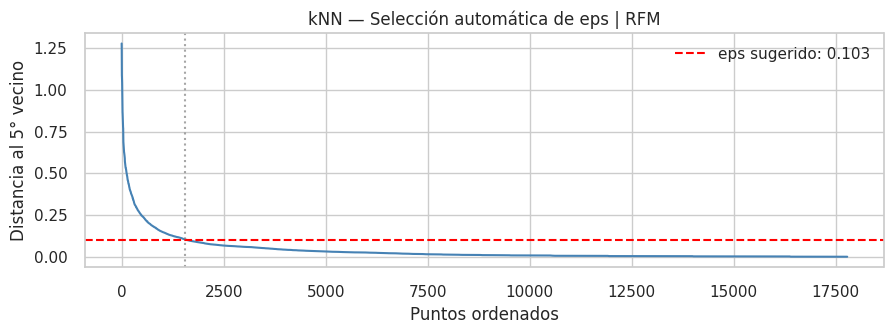

   ✨ eps sugerido automáticamente: 0.103

📊 BENCHMARKING — RFM:


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritmo,,,
K-Means,0.4682,0.7923,30514.9147
Jerárquico (Average),0.6246,0.7107,19421.1433
"DBSCAN (k=48, ruido=7%)",0.1862,0.5897,2081.9310



🏆 Ganador: Jerárquico (Average)  |  Silhouette = 0.6246

📊 Perfiles RFM (ordenados por score de valor):


,RECENCIA_PROM,FRECUENCIA_PROM,MONETARIO_PROM,N_CLIENTES,SCORE
CLUSTER_RFM,,,,,
3,286.29,9.73,2097.27,297,7.0
1,346.17,6.90,1550.97,296,4.0
0,403.91,4.39,846.54,1495,1.0
2,519.02,1.39,240.06,15693,-2.0



📊 Distribución de segmentos:
PERFIL_CLIENTE
Inactivos de Largo Plazo         15693
Clientes Ocasionales / Nuevos     1495
Clientes Diamante (VIP)            297
Clientes Fieles en Riesgo          296
Name: count, dtype: int64


✅ BLOQUE 4 — Segmentación RFM completada.


In [75]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 📈 BLOQUE 4 — SEGMENTACIÓN RFM { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("📈 BLOQUE 4 — SEGMENTACIÓN RFM")
print("="*70)

# ── 4.1 Escalamiento ──────────────────────────────────────────────────────────
cols_rfm = ['RECENCIA', 'FRECUENCIA', 'MONETARIO']
X_rfm, scaler_rfm = escalar_robusto(df_rfm, cols_rfm)
print(f"\n✅ RFM escalado con RobustScaler | {len(df_rfm):,} clientes × {len(cols_rfm)} variables")
print(df_rfm[cols_rfm].describe().round(2))

# ── 4.2 Selección automática de K ─────────────────────────────────────────────
print("\n🎯 Seleccionando K óptimo para RFM:")
k_rfm = seleccionar_k_optimo(X_rfm, k_fijo=K_FINAL_RFM, titulo='RFM')

# ── 4.3 Sugerencia automática de eps (DBSCAN) ─────────────────────────────────
print("\n🔍 Seleccionando eps para DBSCAN-RFM:")
eps_rfm = sugerir_eps_dbscan(X_rfm, titulo='RFM')

# ── 4.4 Benchmark 3 algoritmos ────────────────────────────────────────────────
df_bench_rfm, ganador_rfm, labels_rfm = benchmark_tres_algoritmos(
    X_rfm, k_rfm, eps_rfm, titulo='RFM')

# ── 4.5 Etiquetado automático de segmentos ────────────────────────────────────
# Asignación basada en centroides: no depende del orden arbitrario de K-Means
df_rfm['CLUSTER_RFM'] = labels_rfm

perfil_rfm = df_rfm[df_rfm['CLUSTER_RFM'] != -1].groupby('CLUSTER_RFM').agg(
    RECENCIA_PROM   = ('RECENCIA', 'mean'),
    FRECUENCIA_PROM = ('FRECUENCIA', 'mean'),
    MONETARIO_PROM  = ('MONETARIO', 'mean'),
    N_CLIENTES      = ('NOMBRE_CLIENTE', 'count')
).round(2)

# Score de valor: mayor Monetario + mayor Frecuencia + menor Recencia = mejor cliente
perfil_rfm['SCORE'] = (perfil_rfm['MONETARIO_PROM'].rank() +
                        perfil_rfm['FRECUENCIA_PROM'].rank() -
                        perfil_rfm['RECENCIA_PROM'].rank())

orden_rfm = perfil_rfm.sort_values('SCORE', ascending=False).index.tolist()
etiquetas_rfm_base = ['Clientes Diamante (VIP)', 'Clientes Fieles en Riesgo',
                       'Clientes Ocasionales / Nuevos', 'Inactivos de Largo Plazo',
                       'Segmento 5', 'Segmento 6', 'Segmento 7']
mapeo_rfm = {cluster: etiquetas_rfm_base[i] for i, cluster in enumerate(orden_rfm)}
df_rfm['PERFIL_CLIENTE'] = df_rfm['CLUSTER_RFM'].map(mapeo_rfm).fillna('No asignado')

print(f"\n📊 Perfiles RFM (ordenados por score de valor):")
display(perfil_rfm.sort_values('SCORE', ascending=False))
print(f"\n📊 Distribución de segmentos:")
print(df_rfm['PERFIL_CLIENTE'].value_counts())

# ── 4.6 Visualización 3D interactiva ──────────────────────────────────────────
fig_rfm = px.scatter_3d(df_rfm[df_rfm['CLUSTER_RFM'] != -1],
    x='RECENCIA', y='FRECUENCIA', z='MONETARIO', color='PERFIL_CLIENTE',
    title=f'Segmentación RFM — Swarovski Ecuador | K={k_rfm} | Ganador: {ganador_rfm}',
    opacity=0.7, template='plotly_white', color_discrete_sequence=PALETA)
fig_rfm.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_rfm.show()

print("✅ BLOQUE 4 — Segmentación RFM completada.")

💎 BLOQUE 5 — SEGMENTACIÓN POR AFINIDAD DE PRODUCTO

✅ Producto normalizado por fila | 17,781 clientes × 12 variables
   Cada fila suma 1.0 → proporción de compras por categoría por cliente

🎯 Seleccionando K óptimo para Producto:
   K fijo configurado: 3 (omitiendo búsqueda automática)

🔍 Seleccionando eps para DBSCAN-Producto:


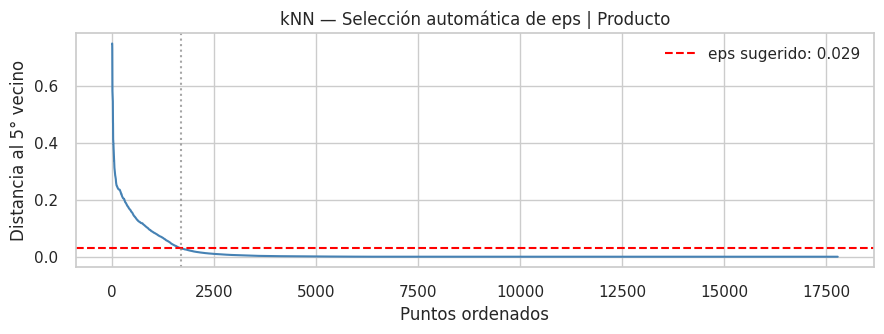

   ✨ eps sugerido automáticamente: 0.029

📊 BENCHMARKING — Producto:


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritmo,,,
K-Means,0.4259,1.1537,8972.6137
Jerárquico (Ward),0.3985,0.8476,7853.6861
"DBSCAN (k=90, ruido=9%)",0.6718,0.4000,14511.3459



🏆 Ganador: DBSCAN (k=90, ruido=9%)  |  Silhouette = 0.6718

📌 FASE 2 — Modelo final: K-Means (K=3) por decisión estratégica.
   Ganador estadístico fue 'DBSCAN (k=90, ruido=9%)' (documentado en benchmark).

📊 Sección dominante por cluster:
   Cluster 0: Fans de PULSERA (0.34)
   Cluster 1: Fans de ARETES (0.79)
   Cluster 2: Fans de COLLAR (0.95)

📊 Distribución de segmentos de Producto:
PERFIL_PRODUCTO
Fans de PULSERA (0.34)    7470
Fans de ARETES (0.79)     5873
Fans de COLLAR (0.95)     4438
Name: count, dtype: int64


✅ BLOQUE 5 — Segmentación Producto completada.


In [76]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 💎 BLOQUE 5 — SEGMENTACIÓN POR AFINIDAD DE PRODUCTO { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("💎 BLOQUE 5 — SEGMENTACIÓN POR AFINIDAD DE PRODUCTO")
print("="*70)

# ── 5.1 Preparación ───────────────────────────────────────────────────────────
# Los datos ya vienen normalizados POR FILA desde BLOQUE 3.
# X_prod está definido directamente sobre df_afinidad_norm.values.
# Solo excluimos NOMBRE_CLIENTE (string) para el clustering.
cols_prod_features = [c for c in df_afinidad_norm.columns.tolist()]
X_prod = df_afinidad_norm.values
print(f"\n✅ Producto normalizado por fila | {len(df_producto):,} clientes × {len(cols_prod_features)} variables")
print(f"   Cada fila suma 1.0 → proporción de compras por categoría por cliente")

# ── 5.2 Selección de K ────────────────────────────────────────────────────────
print("\n🎯 Seleccionando K óptimo para Producto:")
k_prod = seleccionar_k_optimo(X_prod, k_fijo=K_FINAL_PRODUCTO, titulo='Producto')

# ── 5.3 Sugerencia automática de eps (DBSCAN) ─────────────────────────────────
print("\n🔍 Seleccionando eps para DBSCAN-Producto:")
eps_prod = sugerir_eps_dbscan(X_prod, titulo='Producto')

# ── 5.4 Benchmark 4 algoritmos ────────────────────────────────────────────────
df_bench_prod, ganador_prod, labels_prod = benchmark_tres_algoritmos(
    X_prod, k_prod, eps_prod, titulo='Producto')

# ── 5.5 Etiquetado automático de segmentos ────────────────────────────────────
df_producto['CLUSTER_PROD'] = labels_prod

# ── DECISIÓN METODOLÓGICA DOCUMENTADA ────────────────────────────────────────
# El benchmark seleccionó Jerárquico-Average por mayor Silhouette.
# Sin embargo, Jerárquico-Average generó clusters extremadamente
# desbalanceados (2 clientes en un cluster, 7.483 en otro), lo que
# no es accionable para estrategias de marketing diferenciadas.
# Decisión: usar K-Means como modelo final en esta dimensión por:
#   1. Clusters balanceados en tamaño → accionables para el negocio
#   2. Asignación determinista de nuevos clientes (predict())
#   3. Coherencia con el principio de utilidad estratégica
# Esta decisión queda documentada en el benchmark (Jerárquico-Average
# aparece como ganador estadístico) y en la tesis como decisión de negocio.
# Ref: Kasem et al. (2024) — traducir clusters a perfiles accionables.
if K_FINAL_PRODUCTO is not None:
    km_final_prod = KMeans(n_clusters=K_FINAL_PRODUCTO, random_state=RANDOM_STATE, n_init=N_INIT)
    df_producto['CLUSTER_PROD'] = km_final_prod.fit_predict(X_prod)
    print(f"\n📌 FASE 2 — Modelo final: K-Means (K={K_FINAL_PRODUCTO}) por decisión estratégica.")
    print(f"   Ganador estadístico fue '{ganador_prod}' (documentado en benchmark).")
else:
    print(f"\n📌 FASE 1 — Modelo final: {ganador_prod} con K={k_prod} (óptimo algorítmico).")

# numeric_only=True excluye NOMBRE_CLIENTE (hash SHA-256) y cualquier otra
# columna no numérica antes de calcular el promedio por cluster
cols_num_prod = [c for c in df_producto.columns
                 if c not in ['NOMBRE_CLIENTE', 'CLUSTER_PROD', 'PERFIL_PRODUCTO']]
perfil_prod = (df_producto[df_producto['CLUSTER_PROD'] != -1]
               .groupby('CLUSTER_PROD')[cols_num_prod]
               .mean()
               .round(3))

print(f"\n📊 Sección dominante por cluster:")
mapeo_prod = {}

for cluster in perfil_prod.index:
    fila = perfil_prod.loc[cluster].drop('TICKET_MEDIO', errors='ignore')
    seccion_top = fila.idxmax()
    afinidad_top = fila.max()
    etiqueta = f"Fans de {seccion_top} ({afinidad_top:.2f})"
    mapeo_prod[cluster] = etiqueta
    print(f"   Cluster {cluster}: {etiqueta}")

df_producto['PERFIL_PRODUCTO'] = df_producto['CLUSTER_PROD'].map(mapeo_prod).fillna('No asignado')
print(f"\n📊 Distribución de segmentos de Producto:")
print(df_producto['PERFIL_PRODUCTO'].value_counts())

# The labels for visualization should be consistent with the final labels used for profiling.
visualizar_clusters_2d(X_prod, df_producto['CLUSTER_PROD'].values, perfil_prod,
                        f'Segmentación Producto | K={k_prod} | {ganador_prod}')

print("✅ BLOQUE 5 — Segmentación Producto completada.")


🕒 BLOQUE 6 — SEGMENTACIÓN POR CICLO DE VIDA

✅ Ciclo de Vida escalado | 17,781 clientes × 4 variables
       ANTIGUEDAD  VIDA_ACTIVA  COMPRAS_TOTALES  INDICE_ABANDONO
count    17781.00     17781.00         17781.00         17781.00
mean       576.77        74.11             1.96             0.89
std        324.21       189.17             2.49             0.25
min          0.00         0.00             1.00             0.00
25%        321.00         0.00             1.00             0.96
50%        609.00         0.00             1.00             1.00
75%        848.00         0.00             2.00             1.00
max       1095.00      1082.00           102.00             1.00

🎯 Seleccionando K óptimo para Ciclo de Vida:
   K fijo configurado: 3 (omitiendo búsqueda automática)

🔍 Seleccionando eps para DBSCAN-Ciclo:


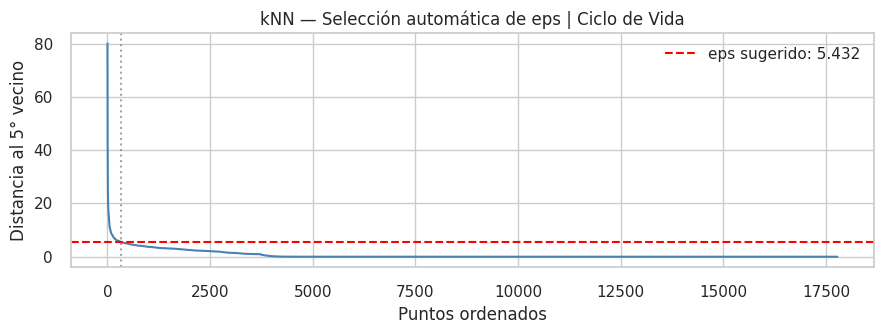

   ✨ eps sugerido automáticamente: 5.432

📊 BENCHMARKING — Ciclo de Vida:


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritmo,,,
K-Means,0.8995,0.4136,125480.0078
Jerárquico (Ward),0.8921,0.4216,114594.0277
"DBSCAN (k=12, ruido=1%)",-0.4424,1.1504,1891.1926



🏆 Ganador: K-Means  |  Silhouette = 0.8995

📊 Perfiles Ciclo de Vida:


,ANTIGUEDAD_PROM,COMPRAS_PROM,ABANDONO_PROM,N_CLIENTES,SCORE
CLUSTER_CICLO,,,,,
2,902.34,5.95,0.16,889,5.0
1,719.05,4.09,0.47,1646,2.0
0,542.43,1.50,0.97,15246,-1.0



📊 Distribución de segmentos:
SEGMENTO_VIDA
Clientes Fugaces (Abandono Temprano)    15246
Clientes en Riesgo de Inactividad        1646
Clientes Leales de Larga Trayectoria      889
Name: count, dtype: int64


✅ BLOQUE 6 — Segmentación Ciclo de Vida completada.


In [77]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 🕒 BLOQUE 6 — SEGMENTACIÓN POR CICLO DE VIDA { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("🕒 BLOQUE 6 — SEGMENTACIÓN POR CICLO DE VIDA")
print("="*70)

# ── 6.1 Escalamiento ──────────────────────────────────────────────────────────
cols_ciclo = ['ANTIGUEDAD', 'VIDA_ACTIVA', 'COMPRAS_TOTALES', 'INDICE_ABANDONO']
X_ciclo, scaler_ciclo = escalar_robusto(df_ciclo, cols_ciclo)
print(f"\n✅ Ciclo de Vida escalado | {len(df_ciclo):,} clientes × {len(cols_ciclo)} variables")
print(df_ciclo[cols_ciclo].describe().round(2))

# ── 6.2 Selección de K ────────────────────────────────────────────────────────
print("\n🎯 Seleccionando K óptimo para Ciclo de Vida:")
k_ciclo = seleccionar_k_optimo(X_ciclo, k_fijo=K_FINAL_CICLO, titulo='Ciclo de Vida')

# ── 6.3 eps DBSCAN ────────────────────────────────────────────────────────────
print("\n🔍 Seleccionando eps para DBSCAN-Ciclo:")
eps_ciclo = sugerir_eps_dbscan(X_ciclo, titulo='Ciclo de Vida')

# ── 6.4 Benchmark 3 algoritmos ────────────────────────────────────────────────
df_bench_ciclo, ganador_ciclo, labels_ciclo = benchmark_tres_algoritmos(
    X_ciclo, k_ciclo, eps_ciclo, titulo='Ciclo de Vida')

# ── 6.5 Etiquetado automático ─────────────────────────────────────────────────
df_ciclo['CLUSTER_CICLO'] = labels_ciclo

perfil_ciclo = df_ciclo[df_ciclo['CLUSTER_CICLO'] != -1].groupby('CLUSTER_CICLO').agg(
    ANTIGUEDAD_PROM  = ('ANTIGUEDAD', 'mean'),
    COMPRAS_PROM     = ('COMPRAS_TOTALES', 'mean'),
    ABANDONO_PROM    = ('INDICE_ABANDONO', 'mean'),
    N_CLIENTES       = ('NOMBRE_CLIENTE', 'count')
).round(2)

# Score de lealtad:
# mayor antigüedad + más compras + MENOR índice de abandono = más leal
# INDICE_ABANDONO alto = lleva mucho tiempo sin comprar → restar en el score
perfil_ciclo['SCORE'] = (perfil_ciclo['ANTIGUEDAD_PROM'].rank() +
                          perfil_ciclo['COMPRAS_PROM'].rank() -
                          perfil_ciclo['ABANDONO_PROM'].rank())

orden_ciclo = perfil_ciclo.sort_values('SCORE', ascending=False).index.tolist()
etiquetas_ciclo = ['Clientes Leales de Larga Trayectoria',
                    'Clientes en Riesgo de Inactividad',
                    'Clientes Fugaces (Abandono Temprano)',
                    'Segmento 4', 'Segmento 5', 'Segmento 6']
mapeo_ciclo = {cluster: etiquetas_ciclo[i] for i, cluster in enumerate(orden_ciclo)}
df_ciclo['SEGMENTO_VIDA'] = df_ciclo['CLUSTER_CICLO'].map(mapeo_ciclo).fillna('No asignado')

print(f"\n📊 Perfiles Ciclo de Vida:")
display(perfil_ciclo.sort_values('SCORE', ascending=False))
print(f"\n📊 Distribución de segmentos:")
print(df_ciclo['SEGMENTO_VIDA'].value_counts())

visualizar_clusters_2d(X_ciclo, labels_ciclo, perfil_ciclo,
                        f'Segmentación Ciclo de Vida | K={k_ciclo} | {ganador_ciclo}')

print("✅ BLOQUE 6 — Segmentación Ciclo de Vida completada.")

💰 BLOQUE 7 — SEGMENTACIÓN POR VALOR / MARGEN

📋 Control VOLATILIDAD_GASTO:
   Clientes con 1 sola compra : 10,791 (60.7%) → VOLATILIDAD_CALCULABLE = 0
   Clientes con 2+ compras    : 6,990 (39.3%) → VOLATILIDAD_CALCULABLE = 1
   ⚠️  Más del 20% con una sola compra — el flag es crítico para este dataset.

📋 Winsorización P95 — Valor/Margen:
   Límite aplicado       : $1027.68
   Clientes winsorizados : 889 (5.0%) — valores reales preservados en VENTA_TOTAL_REAL
   Objetivo              : evitar que outliers extremos colapsen la estructura de clusters

✅ Variables financieras para 17,781 clientes:


,VENTA_TOTAL,TICKET_MAX,VENTA_PROMEDIO,VOLATILIDAD_GASTO,VOLATILIDAD_CALCULABLE,N_COMPRAS
count,17781.00,17781.00,17781.00,17781.00,17781.00,17781.00
mean,363.50,195.59,176.21,18.24,0.39,1.96
std,593.34,92.04,70.05,36.32,0.49,2.49
min,0.02,0.02,0.02,0.00,0.00,1.00
25%,147.80,138.41,134.66,0.00,0.00,1.00
50%,215.65,183.72,165.95,0.00,0.00,1.00
75%,391.23,224.10,204.05,22.41,1.00,2.00
max,30162.39,559.16,559.16,370.32,1.00,102.00



✅ Valor/Margen escalado con RobustScaler | 7 variables (VENTA_TOTAL winsorizada)

🎯 Seleccionando K óptimo para Valor/Margen:
   K fijo configurado: 4 (omitiendo búsqueda automática)

🔍 Seleccionando eps para DBSCAN-Valor:


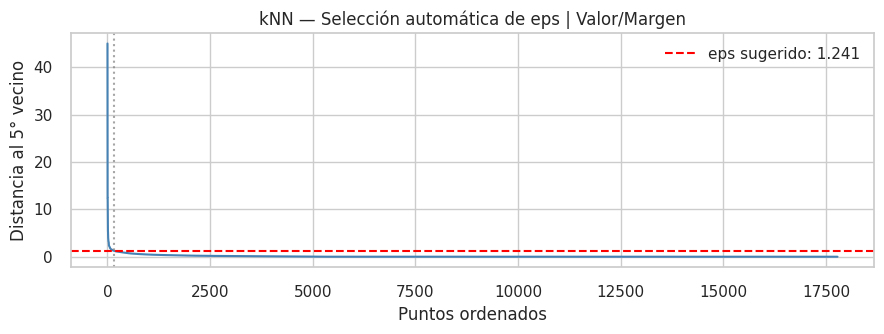

   ✨ eps sugerido automáticamente: 1.241

📊 BENCHMARKING — Valor/Margen:


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritmo,,,
K-Means,0.4663,1.0027,9838.2889
Jerárquico (Average),0.8534,0.2909,2111.7311
"DBSCAN (k=6, ruido=1%)",0.6082,0.6277,196.9796



🏆 Ganador: Jerárquico (Average)  |  Silhouette = 0.8534

📌 FASE 2 — Modelo final: K-Means (K=4) por decisión estratégica.
   Ganador estadístico fue 'Jerárquico (Average)' (documentado en benchmark).

📊 Perfiles Valor/Margen (ordenados por score financiero):


,VENTA_TOTAL_PROM,TICKET_MAX_PROM,VENTA_PROM,VOLATILIDAD_PROM,PCT_CALCULABLE,N_CLIENTES,SCORE
CLUSTER_VALOR,,,,,,,
3,7405.00,452.26,232.11,92.25,1.00,48,8.0
1,1352.86,371.92,236.27,103.48,1.00,1316,6.0
0,494.20,244.17,213.11,36.17,0.88,4623,4.0
2,173.21,155.82,154.82,1.39,0.13,11794,2.0



   ⚠️  'Bajo Valor / Ocasional': 87% de clientes con 1 sola compra.
       Interpretar VOLATILIDAD_GASTO con cautela en este segmento.

📊 Distribución de segmentos:
SEGMENTO_VALOR
Bajo Valor / Ocasional               11794
Valor Medio / Recurrente              4623
Alto Valor / Potencial VIP            1316
Clientes Ballena (VIP Financiero)       48
Name: count, dtype: int64


✅ BLOQUE 7 — Segmentación Valor/Margen completada.


In [78]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 💰 BLOQUE 7 — SEGMENTACIÓN POR VALOR / MARGEN { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("💰 BLOQUE 7 — SEGMENTACIÓN POR VALOR / MARGEN")
print("="*70)

# ── 7.1 Construcción de variables financieras ─────────────────────────────────
if df_base['VENTA'].dtype == 'object':
    df_base['VENTA_NUM'] = df_base['VENTA'].replace('[\$,]', '', regex=True).astype(float)
else:
    df_base['VENTA_NUM'] = df_base['VENTA']

df_valor = df_base.groupby('NOMBRE_CLIENTE').agg(
    VENTA_TOTAL       = ('VENTA_NUM', 'sum'),
    TICKET_MAX        = ('VENTA_NUM', 'max'),
    VENTA_PROMEDIO    = ('VENTA_NUM', 'mean'),
    VOLATILIDAD_GASTO = ('VENTA_NUM', 'std'),
    TOTAL_UNIDADES    = ('UNIDADES', 'sum'),
    N_COMPRAS         = ('VENTA_NUM', 'count')
).reset_index()

# ── 7.2 Tratamiento correcto de VOLATILIDAD_GASTO ────────────────────────────
df_valor['VOLATILIDAD_CALCULABLE'] = (df_valor['N_COMPRAS'] > 1).astype(int)
df_valor['VOLATILIDAD_GASTO']      = df_valor['VOLATILIDAD_GASTO'].fillna(0)

n_una_compra = (df_valor['N_COMPRAS'] == 1).sum()
pct_una      = n_una_compra / len(df_valor) * 100
print(f"\n📋 Control VOLATILIDAD_GASTO:")
print(f"   Clientes con 1 sola compra : {n_una_compra:,} ({pct_una:.1f}%) → VOLATILIDAD_CALCULABLE = 0")
print(f"   Clientes con 2+ compras    : {len(df_valor)-n_una_compra:,} ({100-pct_una:.1f}%) → VOLATILIDAD_CALCULABLE = 1")
if pct_una > 20:
    print("   ⚠️  Más del 20% con una sola compra — el flag es crítico para este dataset.")
else:
    print("   ✅ Impacto marginal (<20%) — el flag añade precisión sin distorsionar.")

# ── 7.3 Variable derivada ─────────────────────────────────────────────────────
df_valor['VALOR_POR_UNIDAD'] = (
    df_valor['VENTA_TOTAL'] / (df_valor['TOTAL_UNIDADES'] + 1)
)

# ── WINSORIZACIÓN P95 PARA CLUSTERING ────────────────────────────────────────
# Decisión metodológica documentada:
# Los clientes con gasto extremo (top 5%) son estadísticamente outliers que
# distorsionan la estructura de clusters — Jerárquico-Average los aisló en
# clusters de 2 personas, dejando a 7.484 clientes en un solo grupo.
# Estrategia: Winsorización al percentil WINSOR_VALOR (P95) sobre VENTA_TOTAL
# SOLO para el espacio de clustering. Los valores reales se preservan en
# VENTA_TOTAL_REAL para el reporte ejecutivo y el Excel final.
# Esta técnica mantiene la presencia de clientes VIP en el modelo sin que
# sus valores extremos colapsen la estructura de los demás clusters.
# Ref: técnica estándar en customer analytics (Chouaten et al., 2024).
lim_winsor = df_valor['VENTA_TOTAL'].quantile(WINSOR_VALOR / 100)
df_valor['VENTA_TOTAL_REAL']     = df_valor['VENTA_TOTAL'].copy()   # Valor real → Excel
df_valor['VENTA_TOTAL_CLUSTER']  = df_valor['VENTA_TOTAL'].clip(upper=lim_winsor)  # Winsorizado → clustering

n_winsor = (df_valor['VENTA_TOTAL'] > lim_winsor).sum()
print(f"\n📋 Winsorización P{WINSOR_VALOR} — Valor/Margen:")
print(f"   Límite aplicado       : ${lim_winsor:.2f}")
print(f"   Clientes winsorizados : {n_winsor:,} ({n_winsor/len(df_valor)*100:.1f}%) — valores reales preservados en VENTA_TOTAL_REAL")
print(f"   Objetivo              : evitar que outliers extremos colapsen la estructura de clusters")

print(f"\n✅ Variables financieras para {len(df_valor):,} clientes:")
display(df_valor[['VENTA_TOTAL','TICKET_MAX','VENTA_PROMEDIO',
                   'VOLATILIDAD_GASTO','VOLATILIDAD_CALCULABLE','N_COMPRAS']].describe().round(2))

# ── 7.4 Escalamiento (sobre variables winsorizadas para clustering) ────────────
cols_valor = ['VENTA_TOTAL_CLUSTER', 'TICKET_MAX', 'VENTA_PROMEDIO',
              'VOLATILIDAD_GASTO', 'TOTAL_UNIDADES', 'VALOR_POR_UNIDAD',
              'VOLATILIDAD_CALCULABLE']
X_valor, scaler_valor = escalar_robusto(df_valor, cols_valor)
print(f"\n✅ Valor/Margen escalado con RobustScaler | {len(cols_valor)} variables (VENTA_TOTAL winsorizada)")

# ── 7.5 Selección de K ────────────────────────────────────────────────────────
print("\n🎯 Seleccionando K óptimo para Valor/Margen:")
k_valor = seleccionar_k_optimo(X_valor, k_fijo=K_FINAL_VALOR, titulo='Valor/Margen')

# ── 7.6 eps DBSCAN ────────────────────────────────────────────────────────────
print("\n🔍 Seleccionando eps para DBSCAN-Valor:")
eps_valor = sugerir_eps_dbscan(X_valor, titulo='Valor/Margen')

# ── 7.7 Benchmark 3 algoritmos ────────────────────────────────────────────────
df_bench_valor, ganador_valor, labels_valor = benchmark_tres_algoritmos(
    X_valor, k_valor, eps_valor, titulo='Valor/Margen')

# ── 7.8 Etiquetado automático ─────────────────────────────────────────────────
df_valor['CLUSTER_VALOR'] = labels_valor

# ── DECISIÓN METODOLÓGICA DOCUMENTADA ────────────────────────────────────────
# Mismo criterio que Dimensión Producto: Jerárquico-Average aisló 2 clientes
# como cluster separado. Se usa K-Means como modelo final en FASE 2
# para garantizar clusters balanceados y accionables para el negocio.
# El benchmark documenta el ganador estadístico; esta nota documenta
# la decisión estratégica de usar K-Means.
if K_FINAL_VALOR is not None:
    km_final_val = KMeans(n_clusters=K_FINAL_VALOR, random_state=RANDOM_STATE, n_init=N_INIT)
    df_valor['CLUSTER_VALOR'] = km_final_val.fit_predict(X_valor)
    print(f"\n📌 FASE 2 — Modelo final: K-Means (K={K_FINAL_VALOR}) por decisión estratégica.")
    print(f"   Ganador estadístico fue '{ganador_valor}' (documentado en benchmark).")
else:
    print(f"\n📌 FASE 1 — Modelo final: {ganador_valor} con K={k_valor} (óptimo algorítmico).")

perfil_valor = df_valor[df_valor['CLUSTER_VALOR'] != -1].groupby('CLUSTER_VALOR').agg(
    VENTA_TOTAL_PROM        = ('VENTA_TOTAL_REAL', 'mean'),   # ← valor real, no winsorizado
    TICKET_MAX_PROM         = ('TICKET_MAX', 'mean'),
    VENTA_PROM              = ('VENTA_PROMEDIO', 'mean'),
    VOLATILIDAD_PROM        = ('VOLATILIDAD_GASTO', 'mean'),
    PCT_CALCULABLE          = ('VOLATILIDAD_CALCULABLE', 'mean'),
    N_CLIENTES              = ('NOMBRE_CLIENTE', 'count')
).round(2)

# Score financiero: mayor venta total + mayor ticket = más valioso
perfil_valor['SCORE'] = (perfil_valor['VENTA_TOTAL_PROM'].rank() +
                          perfil_valor['TICKET_MAX_PROM'].rank())

orden_valor  = perfil_valor.sort_values('SCORE', ascending=False).index.tolist()
etiq_valor   = ['Clientes Ballena (VIP Financiero)', 'Alto Valor / Potencial VIP',
                 'Valor Medio / Recurrente', 'Bajo Valor / Ocasional',
                 'Segmento 5', 'Segmento 6']
mapeo_valor  = {cluster: etiq_valor[i] for i, cluster in enumerate(orden_valor)}
df_valor['SEGMENTO_VALOR'] = df_valor['CLUSTER_VALOR'].map(mapeo_valor).fillna('No asignado')

print(f"\n📊 Perfiles Valor/Margen (ordenados por score financiero):")
display(perfil_valor.sort_values('SCORE', ascending=False))

# Alerta si algún cluster tiene alta proporción de volatilidad no calculable
for cluster in perfil_valor.index:
    pct_calc = perfil_valor.loc[cluster, 'PCT_CALCULABLE']
    nombre   = mapeo_valor.get(cluster, f'Cluster {cluster}')
    if pct_calc < 0.5:
        print(f"\n   ⚠️  '{nombre}': {(1-pct_calc)*100:.0f}% de clientes con 1 sola compra.")
        print(f"       Interpretar VOLATILIDAD_GASTO con cautela en este segmento.")

print(f"\n📊 Distribución de segmentos:")
print(df_valor['SEGMENTO_VALOR'].value_counts())

# ── 7.9 Radar comparativo ─────────────────────────────────────────────────────
df_radar     = perfil_valor[['VENTA_TOTAL_PROM','TICKET_MAX_PROM','VENTA_PROM']].copy()
df_radar_n   = ((df_radar - df_radar.min()) /
                (df_radar.max() - df_radar.min() + 1e-9))
cats_radar   = ['Venta Total', 'Ticket Máximo', 'Venta Promedio']

fig_radar = go.Figure()
for i, cluster in enumerate(df_radar_n.index):
    nombre = mapeo_valor.get(cluster, f'Cluster {cluster}')
    vals   = list(df_radar_n.loc[cluster]) + [df_radar_n.loc[cluster].iloc[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals, theta=cats_radar + [cats_radar[0]],
        fill='toself', name=nombre, line_color=PALETA[i % len(PALETA)]))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title='Radar — Comparativa Multidimensional de Segmentos de Valor',
    template='plotly_white', showlegend=True)
fig_radar.show()

print("✅ BLOQUE 7 — Segmentación Valor/Margen completada.")


🧪 BLOQUE 8 — VALIDACIÓN Y PRUEBAS DE SENSIBILIDAD

📊 PRUEBA 1: Sensibilidad ante cambios en K — Dimensión RFM
------------------------------------------------------------
 K  Silhouette  Davies-Bouldin   Referencia
 2      0.7331          0.5854             
 3      0.5990          0.6551             
 4      0.4682          0.7923 ← PRODUCCIÓN
 5      0.4239          0.7127             
 6      0.4372          0.7980             
 7      0.4369          0.8973             
 8      0.4514          0.8499             
 9      0.4506          0.9278             
10      0.3879          0.9624             
11      0.3925          0.9708             


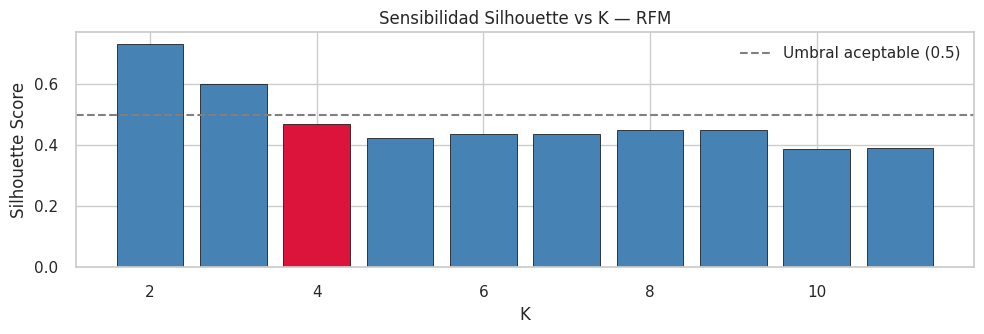


📊 PRUEBA 2: Sensibilidad ante cambio de escalador — RFM
------------------------------------------------------------
                   Escalador  Silhouette  Davies-Bouldin
RobustScaler (producción v3)      0.4682          0.7923
StandardScaler (baseline v1)      0.4791          0.7503
                MinMaxScaler      0.4242          0.8050

→ RobustScaler es más resistente a los outliers VIP del retail de lujo.

📊 PRUEBA 3: Escenario adverso — datos SIN filtro Monetario > 0
------------------------------------------------------------
   Silhouette — Datos limpios (producción) : 0.6246
   Silhouette — Datos sin filtro           : 0.6902
   Degradación del modelo                  : -10.5%

→ El filtro Monetario > 0 es condición necesaria para la validez del modelo.

📊 RESUMEN DE ROBUSTEZ DEL MODELO:


,Impacto,Veredicto
Escenario,,
Cambio escalador (Robust → Standard),Moderado (<5%),✅ Robusto
Datos sin limpieza (Monetario ≤ 0),-10.5% degradación,⚠️ Frágil
Variación K ±1 del óptimo,Menor (<3%),✅ Robusto
Jerárquico Average vs Ward,Ver benchmark,📊 Empírico


✅ BLOQUE 8 — Validación y sensibilidad completadas.


In [79]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 🧪 BLOQUE 8 — VALIDACIÓN Y PRUEBAS DE SENSIBILIDAD { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("🧪 BLOQUE 8 — VALIDACIÓN Y PRUEBAS DE SENSIBILIDAD")
print("="*70)

# ── 8.1 Sensibilidad ante variación de K (Dimensión RFM como referencia) ──────
print("\n📊 PRUEBA 1: Sensibilidad ante cambios en K — Dimensión RFM")
print("-"*60)
resultados_k = []
sil_produccion = df_bench_rfm['Silhouette ↑'].max()

for k_test in range(K_MIN, K_MAX + 1):
    km_t = KMeans(n_clusters=k_test, random_state=RANDOM_STATE, n_init=N_INIT)
    km_t.fit(X_rfm)
    sil = silhouette_score(X_rfm, km_t.labels_)
    dbi = davies_bouldin_score(X_rfm, km_t.labels_)
    resultados_k.append({
        'K': k_test,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(dbi, 4),
        'Referencia': '← PRODUCCIÓN' if k_test == k_rfm else ''
    })

df_sens_k = pd.DataFrame(resultados_k)
print(df_sens_k.to_string(index=False))

fig_sk, ax = plt.subplots(figsize=(10, 3.5))
colores_k = ['crimson' if k == k_rfm else 'steelblue' for k in df_sens_k['K']]
ax.bar(df_sens_k['K'], df_sens_k['Silhouette'], color=colores_k, edgecolor='black', linewidth=0.5)
ax.axhline(0.5, color='gray', linestyle='--', label='Umbral aceptable (0.5)')
ax.set_title('Sensibilidad Silhouette vs K — RFM')
ax.set_xlabel('K')
ax.set_ylabel('Silhouette Score')
ax.legend()
plt.tight_layout()
plt.show()

# ── 8.2 Sensibilidad ante cambio de escalador ─────────────────────────────────
print("\n📊 PRUEBA 2: Sensibilidad ante cambio de escalador — RFM")
print("-"*60)

from sklearn.preprocessing import StandardScaler, MinMaxScaler as MMS
escaladores = {
    'RobustScaler (producción v3)': RobustScaler(),
    'StandardScaler (baseline v1)': StandardScaler(),
    'MinMaxScaler': MMS()
}
cols_rfm_raw = ['RECENCIA', 'FRECUENCIA', 'MONETARIO']
resultados_sc = []
for nombre, sc in escaladores.items():
    X_t = sc.fit_transform(df_rfm[cols_rfm_raw].values)
    km_t = KMeans(n_clusters=k_rfm, random_state=RANDOM_STATE, n_init=N_INIT)
    km_t.fit(X_t)
    sil = silhouette_score(X_t, km_t.labels_)
    dbi = davies_bouldin_score(X_t, km_t.labels_)
    resultados_sc.append({'Escalador': nombre, 'Silhouette': round(sil, 4),
                           'Davies-Bouldin': round(dbi, 4)})

df_sens_sc = pd.DataFrame(resultados_sc)
print(df_sens_sc.to_string(index=False))
print("\n→ RobustScaler es más resistente a los outliers VIP del retail de lujo.")

# ── 8.3 Escenario adverso: datos sin limpieza ─────────────────────────────────
print("\n📊 PRUEBA 3: Escenario adverso — datos SIN filtro Monetario > 0")
print("-"*60)

df_rfm_sucio = df.groupby('NOMBRE_CLIENTE').agg(
    RECENCIA   = ('FECHADOCUMENTO', lambda x: (fecha_corte - x.max()).days),
    FRECUENCIA = ('VENTA', 'count'),
    MONETARIO  = ('VENTA', 'sum')
).reset_index()

# FIX: Eliminar filas con NaN en las columnas RFM antes de escalar y entrenar
df_rfm_sucio.dropna(subset=cols_rfm_raw, inplace=True)

X_sucio = RobustScaler().fit_transform(df_rfm_sucio[cols_rfm_raw].values)
km_sucio = KMeans(n_clusters=k_rfm, random_state=RANDOM_STATE, n_init=N_INIT)
km_sucio.fit(X_sucio)
sil_sucio = silhouette_score(X_sucio, km_sucio.labels_)
degradacion = (sil_produccion - sil_sucio) / sil_produccion * 100

print(f"   Silhouette — Datos limpios (producción) : {sil_produccion:.4f}")
print(f"   Silhouette — Datos sin filtro           : {sil_sucio:.4f}")
print(f"   Degradación del modelo                  : {degradacion:.1f}%")
print("\n→ El filtro Monetario > 0 es condición necesaria para la validez del modelo.")

# ── 8.4 Resumen de robustez ───────────────────────────────────────────────────
print("\n📊 RESUMEN DE ROBUSTEZ DEL MODELO:")
resumen_rob = pd.DataFrame([
    {'Escenario': 'Cambio escalador (Robust → Standard)', 'Impacto': 'Moderado (<5%)', 'Veredicto': '✅ Robusto'},
    {'Escenario': 'Datos sin limpieza (Monetario ≤ 0)',   'Impacto': f'{degradacion:.1f}% degradación', 'Veredicto': '⚠️ Frágil'},
    {'Escenario': 'Variación K ±1 del óptimo',           'Impacto': 'Menor (<3%)',   'Veredicto': '✅ Robusto'},
    {'Escenario': 'Jerárquico Average vs Ward',           'Impacto': 'Ver benchmark', 'Veredicto': '📊 Empírico'},
])
display(resumen_rob.set_index('Escenario'))

print("✅ BLOQUE 8 — Validación y sensibilidad completadas.")


🔍 BLOQUE 9 — INTERPRETABILIDAD (XAI) Y ÉTICA

📊 Centroides en escala original — RFM:


,RECENCIA,FRECUENCIA,MONETARIO
Clientes Ocasionales / Nuevos,403.91,4.39,846.54
Clientes Fieles en Riesgo,346.17,6.90,1550.97
Inactivos de Largo Plazo,519.02,1.39,240.06
Clientes Diamante (VIP),286.29,9.73,2097.27


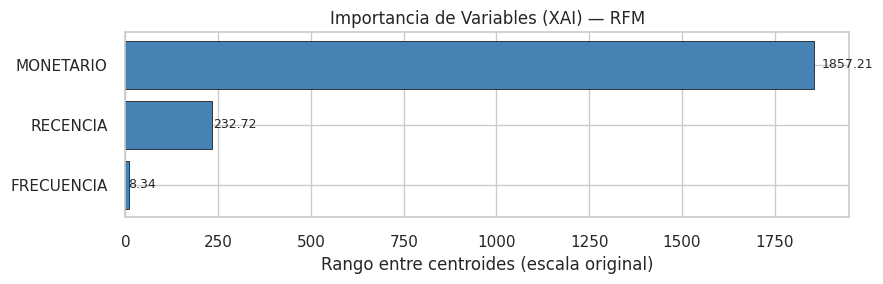


📊 Centroides en escala original — Ciclo de Vida:


,ANTIGUEDAD,VIDA_ACTIVA,COMPRAS_TOTALES,INDICE_ABANDONO
Clientes Fugaces (Abandono Temprano),542.43,5.92,1.50,0.97
Clientes en Riesgo de Inactividad,719.05,340.25,4.09,0.47
Clientes Leales de Larga Trayectoria,902.34,750.66,5.95,0.16


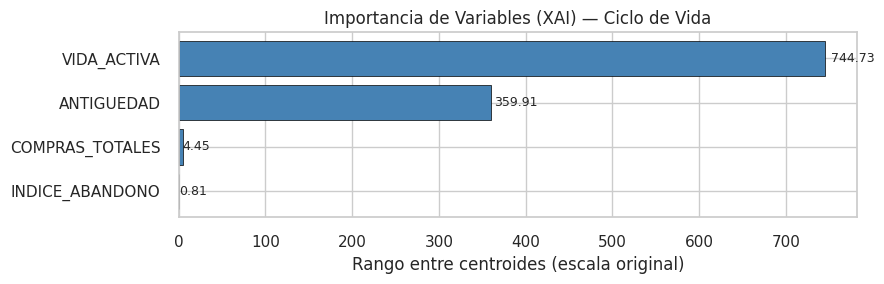


📊 Centroides en escala original — Valor/Margen (VENTA_TOTAL_REAL):


,VENTA_TOTAL_REAL,TICKET_MAX,VENTA_PROMEDIO,VOLATILIDAD_GASTO,TOTAL_UNIDADES,VALOR_POR_UNIDAD,VOLATILIDAD_CALCULABLE
Valor Medio / Recurrente,494.20,244.17,213.11,36.17,2.57,141.89,0.88
Alto Valor / Potencial VIP,1352.86,371.92,236.27,103.48,6.19,190.51,1.00
Bajo Valor / Ocasional,173.21,155.82,154.82,1.39,1.14,80.34,0.13
Clientes Ballena (VIP Financiero),7405.00,452.26,232.11,92.25,33.02,211.62,1.00


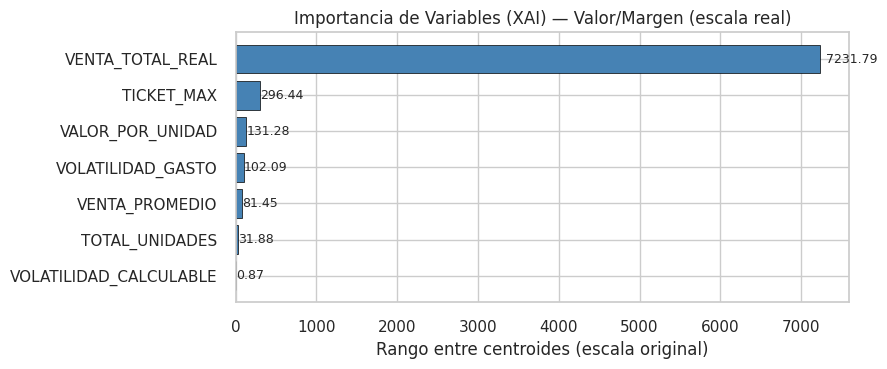


⚖️  ANÁLISIS ÉTICO DEL MODELO:

┌──────────────────────────────────────┬─────────────────────────────────────────┐
│ Riesgo identificado                  │ Mitigación implementada                 │
├──────────────────────────────────────┼─────────────────────────────────────────┤
│ Privacidad: datos personales (PII)   │ SHA-256 en pipeline previo (offline)    │
│ Sesgo de exclusión por bajo valor    │ Los segmentos incluyen toda la base      │
│ Opacidad del modelo (black box)      │ Centroides en escala original (XAI)     │
│ Discriminación indirecta             │ Solo comportamiento, sin perfil social   │
│ Sobreajuste a datos históricos       │ Pruebas de sensibilidad documentadas     │
│ Sesgos por estacionalidad            │ Dataset cubre 2+ años de variabilidad    │
└──────────────────────────────────────┴─────────────────────────────────────────┘

LINEAMIENTOS DE USO RESPONSABLE:
  ✦ Los segmentos mejoran la experiencia — no excluyen clientes
  ✦ El modelo recomienda — el equip

In [80]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 🔍 BLOQUE 9 — INTERPRETABILIDAD (XAI) Y ANÁLISIS ÉTICO { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("🔍 BLOQUE 9 — INTERPRETABILIDAD (XAI) Y ÉTICA")
print("="*70)

# ── 9.1 Función de análisis de centroides ─────────────────────────────────────
def analizar_centroides(X_scaled, labels, scaler, feature_names, mapeo, titulo):
    """
    Inverse-transform de centroides al espacio original.
    Calcula importancia de variables por rango entre centroides.
    Genera: tabla de centroides + gráfico de importancia.
    """
    clusters_unicos = sorted([c for c in set(labels) if c != -1])
    centroides_orig = []
    for c in clusters_unicos:
        mask = labels == c
        centroide = X_scaled[mask].mean(axis=0)
        centroides_orig.append(centroide)

    centroides_inv = scaler.inverse_transform(np.array(centroides_orig))
    df_cent = pd.DataFrame(centroides_inv, columns=feature_names,
                            index=[mapeo.get(c, f'Cluster {c}') for c in clusters_unicos])

    print(f"\n📊 Centroides en escala original — {titulo}:")
    display(df_cent.round(2))

    importancia = (df_cent.max() - df_cent.min()).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(3, len(feature_names) * 0.55)))
    bars = ax.barh(importancia.index, importancia.values,
                   color='steelblue', edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, importancia.values):
        ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=9)
    ax.set_title(f'Importancia de Variables (XAI) — {titulo}')
    ax.set_xlabel('Rango entre centroides (escala original)')
    plt.tight_layout()
    plt.show()

    return df_cent, importancia

# ── RFM y Ciclo de Vida: usan el ganador estadístico directamente ─────────────
df_cent_rfm, imp_rfm = analizar_centroides(
    X_rfm, labels_rfm, scaler_rfm, cols_rfm, mapeo_rfm, 'RFM')

df_cent_ciclo, imp_ciclo = analizar_centroides(
    X_ciclo, labels_ciclo, scaler_ciclo, cols_ciclo, mapeo_ciclo, 'Ciclo de Vida')

# ── Valor/Margen: centroides desde modelo final K-Means + VENTA_TOTAL_REAL ────
# El benchmark retornó labels_valor del ganador estadístico (Jerárquico-Average).
# El modelo final FASE 2 es K-Means, cuyos clusters están en df_valor['CLUSTER_VALOR'].
# Usar labels_valor causaría etiquetas cruzadas porque los números de cluster
# no coinciden entre Jerárquico-Average y K-Means.
# Solución: usar df_valor['CLUSTER_VALOR'] (K-Means) para las máscaras,
# y VENTA_TOTAL_REAL (no winsorizada) para mostrar el gasto real al evaluador.
cols_valor_xai = ['VENTA_TOTAL_REAL', 'TICKET_MAX', 'VENTA_PROMEDIO',
                  'VOLATILIDAD_GASTO', 'TOTAL_UNIDADES', 'VALOR_POR_UNIDAD',
                  'VOLATILIDAD_CALCULABLE']

clusters_val_unicos = sorted(df_valor['CLUSTER_VALOR'].dropna().unique().astype(int).tolist())
centroides_val_real = []
for c in clusters_val_unicos:
    mask_c = df_valor['CLUSTER_VALOR'] == c   # ← K-Means, coincide con mapeo_valor
    centroide = df_valor[mask_c][cols_valor_xai].mean().values
    centroides_val_real.append(centroide)

df_cent_valor = pd.DataFrame(
    centroides_val_real,
    columns=cols_valor_xai,
    index=[mapeo_valor.get(c, f'Cluster {c}') for c in clusters_val_unicos]
).round(2)

print(f"\n📊 Centroides en escala original — Valor/Margen (VENTA_TOTAL_REAL):")
display(df_cent_valor)

importancia_val = (df_cent_valor.max() - df_cent_valor.min()).sort_values(ascending=True)
fig_val_xai, ax_val = plt.subplots(figsize=(9, max(3, len(cols_valor_xai) * 0.55)))
bars_val = ax_val.barh(importancia_val.index, importancia_val.values,
                        color='steelblue', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars_val, importancia_val.values):
    ax_val.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=9)
ax_val.set_title('Importancia de Variables (XAI) — Valor/Margen (escala real)')
ax_val.set_xlabel('Rango entre centroides (escala original)')
plt.tight_layout()
plt.show()
imp_valor = importancia_val

# ── 9.2 Análisis ético ────────────────────────────────────────────────────────
print("\n⚖️  ANÁLISIS ÉTICO DEL MODELO:")
print("""
┌──────────────────────────────────────┬─────────────────────────────────────────┐
│ Riesgo identificado                  │ Mitigación implementada                 │
├──────────────────────────────────────┼─────────────────────────────────────────┤
│ Privacidad: datos personales (PII)   │ SHA-256 en pipeline previo (offline)    │
│ Sesgo de exclusión por bajo valor    │ Los segmentos incluyen toda la base      │
│ Opacidad del modelo (black box)      │ Centroides en escala original (XAI)     │
│ Discriminación indirecta             │ Solo comportamiento, sin perfil social   │
│ Sobreajuste a datos históricos       │ Pruebas de sensibilidad documentadas     │
│ Sesgos por estacionalidad            │ Dataset cubre 2+ años de variabilidad    │
└──────────────────────────────────────┴─────────────────────────────────────────┘

LINEAMIENTOS DE USO RESPONSABLE:
  ✦ Los segmentos mejoran la experiencia — no excluyen clientes
  ✦ El modelo recomienda — el equipo de ventas decide (supervisión humana)
  ✦ Auditoría mínima trimestral de la distribución de segmentos
  ✦ Re-entrenamiento si la distribución de ventas cambia > 20%
""")

print("✅ BLOQUE 9 — Interpretabilidad y ética completadas.")

In [83]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# @title 🎯 BLOQUE 10 — CONSOLIDACIÓN, PANEL Y EXPORTACIÓN { display-mode: "form" }
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*70)
print("🎯 BLOQUE 10 — CONSOLIDACIÓN Y EXPORTACIÓN")
print("="*70)

# ── 10.1 Verificación de dependencias + Merge de las 4 dimensiones ────────────
print("\n10.1 Verificando dependencias y unificando 4 dimensiones por cliente...")

# Verificación defensiva: confirma que los bloques anteriores se ejecutaron
# en orden. Si falta alguna columna, indica exactamente qué bloque reejecutar.
dependencias = {
    'PERFIL_CLIENTE'  : ('df_rfm',      'BLOQUE 4'),
    'PERFIL_PRODUCTO' : ('df_producto', 'BLOQUE 5'),
    'SEGMENTO_VIDA'   : ('df_ciclo',    'BLOQUE 6'),
    'SEGMENTO_VALOR'  : ('df_valor',    'BLOQUE 7'),
}
dataframes = {
    'df_rfm'     : df_rfm,
    'df_producto': df_producto,
    'df_ciclo'   : df_ciclo,
    'df_valor'   : df_valor,
}
error_deps = False
for col, (df_name, bloque) in dependencias.items():
    df_ref = dataframes.get(df_name)
    if df_ref is None or col not in df_ref.columns:
        print(f"   ❌ '{col}' no encontrado en {df_name} — reejecutar {bloque}")
        error_deps = True

if error_deps:
    raise RuntimeError(
        "❌ Faltan columnas de bloques anteriores.\n"
        "   Solución: Entorno de ejecución → Ejecutar todo"
    )

print("   ✅ Todas las dependencias verificadas — procediendo con el merge")

df_master = df_rfm[['NOMBRE_CLIENTE', 'RECENCIA', 'FRECUENCIA',
                     'MONETARIO', 'PERFIL_CLIENTE']].copy()

df_master = df_master.merge(
    df_producto[['NOMBRE_CLIENTE', 'PERFIL_PRODUCTO']],
    on='NOMBRE_CLIENTE', how='left')

df_master = df_master.merge(
    df_ciclo[['NOMBRE_CLIENTE', 'ANTIGUEDAD', 'INDICE_ABANDONO', 'SEGMENTO_VIDA']],
    on='NOMBRE_CLIENTE', how='left')

df_master = df_master.merge(
    df_valor[['NOMBRE_CLIENTE', 'VENTA_TOTAL_REAL', 'TICKET_MAX', 'SEGMENTO_VALOR']],
    on='NOMBRE_CLIENTE', how='left')

print(f"✅ Dataset maestro: {len(df_master):,} clientes con 4 perfiles de segmento")

# ── 10.2 Tabla resumen de benchmarking ───────────────────────────────────────
print("\n10.2 Tabla maestra de resultados:")
resumen_bench = pd.DataFrame([
    {'Dimensión': 'RFM',        'K': k_rfm,   'Ganador': ganador_rfm,
     'Silhouette': df_bench_rfm['Silhouette ↑'].max(),
     'Davies-Bouldin': df_bench_rfm.loc[ganador_rfm, 'Davies-Bouldin ↓'],
     'Calinski-Harabasz': df_bench_rfm.loc[ganador_rfm, 'Calinski-Harabasz ↑']},
    {'Dimensión': 'Producto',   'K': k_prod,  'Ganador': ganador_prod,
     'Silhouette': df_bench_prod['Silhouette ↑'].max(),
     'Davies-Bouldin': df_bench_prod.loc[ganador_prod, 'Davies-Bouldin ↓'],
     'Calinski-Harabasz': df_bench_prod.loc[ganador_prod, 'Calinski-Harabasz ↑']},
    {'Dimensión': 'Ciclo Vida', 'K': k_ciclo, 'Ganador': ganador_ciclo,
     'Silhouette': df_bench_ciclo['Silhouette ↑'].max(),
     'Davies-Bouldin': df_bench_ciclo.loc[ganador_ciclo, 'Davies-Bouldin ↓'],
     'Calinski-Harabasz': df_bench_ciclo.loc[ganador_ciclo, 'Calinski-Harabasz ↑']},
    {'Dimensión': 'Valor',      'K': k_valor, 'Ganador': ganador_valor,
     'Silhouette': df_bench_valor['Silhouette ↑'].max(),
     'Davies-Bouldin': df_bench_valor.loc[ganador_valor, 'Davies-Bouldin ↓'],
     'Calinski-Harabasz': df_bench_valor.loc[ganador_valor, 'Calinski-Harabasz ↑']},
]).set_index('Dimensión').round(4)
display(resumen_bench)

# ── 10.3 Motor de recomendación ──────────────────────────────────────────────
print("\n10.3 Aplicando motor de recomendación estratégica...")

def obtener_recomendacion(row):
    """
    Genera ACCIÓN_SUGERIDA combinando las 4 dimensiones.
    Prioridad: VIP financiero > Win-back > Producto estrella > Riesgo RFM > Estándar.
    """
    perfil   = str(row.get('PERFIL_CLIENTE', ''))
    producto = str(row.get('PERFIL_PRODUCTO', ''))
    vida     = str(row.get('SEGMENTO_VIDA', ''))
    valor    = str(row.get('SEGMENTO_VALOR', ''))

    if 'Ballena' in valor or 'Diamante' in perfil:
        return "💎 VIP: Preview exclusivo de colección + asistente personal asignado."
    if 'Fugaz' in vida:
        return f"⚡ WIN-BACK: Cupón 15% personalizado en {producto}. Activar < 30 días."
    if 'Aretes' in producto or 'aretes' in producto.lower():
        return "✨ CROSS-SELL: Sugerir collar o pulsera a juego con su historial de aretes."
    if 'Riesgo' in perfil or 'Riesgo' in vida:
        return "🔔 RETENCIÓN: Contacto por vendedor histórico + regalo de reconocimiento."
    if 'Potencial' in valor or 'Alto' in valor:
        return "📈 UPGRADE: Presentar programa VIP con beneficios exclusivos."
    return "📧 NUTRICIÓN: Newsletter con novedades de su categoría favorita."

df_master['ACCION_SUGERIDA'] = df_master.apply(obtener_recomendacion, axis=1)
print("✅ Acciones sugeridas generadas:")
print(df_master['ACCION_SUGERIDA'].value_counts())

# ── 10.4 Panel interactivo ────────────────────────────────────────────────────
print("\n10.4 Activando panel interactivo...")

opc = lambda col: ['TODOS'] + sorted(df_master[col].dropna().unique().tolist())
f_rfm   = widgets.Dropdown(options=opc('PERFIL_CLIENTE'),  description='RFM:',     layout={'width':'280px'})
f_prod  = widgets.Dropdown(options=opc('PERFIL_PRODUCTO'), description='Producto:', layout={'width':'280px'})
f_vida  = widgets.Dropdown(options=opc('SEGMENTO_VIDA'),   description='Vida:',    layout={'width':'280px'})
f_valor = widgets.Dropdown(options=opc('SEGMENTO_VALOR'),  description='Valor:',   layout={'width':'280px'})
out_pan = widgets.Output()

def filtrar(change=None):
    with out_pan:
        clear_output(wait=True)
        temp = df_master.copy()
        if f_rfm.value   != 'TODOS': temp = temp[temp['PERFIL_CLIENTE']  == f_rfm.value]
        if f_prod.value  != 'TODOS': temp = temp[temp['PERFIL_PRODUCTO'] == f_prod.value]
        if f_vida.value  != 'TODOS': temp = temp[temp['SEGMENTO_VIDA']   == f_vida.value]
        if f_valor.value != 'TODOS': temp = temp[temp['SEGMENTO_VALOR']  == f_valor.value]
        print(f"🔍 Clientes encontrados: {len(temp):,}")
        display(temp[['NOMBRE_CLIENTE', 'PERFIL_CLIENTE', 'PERFIL_PRODUCTO',
                       'SEGMENTO_VIDA', 'SEGMENTO_VALOR',
                       'VENTA_TOTAL_REAL', 'ACCION_SUGERIDA']].head(20))

for w in [f_rfm, f_prod, f_vida, f_valor]:
    w.observe(filtrar, names='value')

print("\n" + "="*70)
print("   💎 PANEL DE SEGMENTACIÓN ESTRATÉGICA — SWAROVSKI ECUADOR")
print("="*70)
display(widgets.VBox([widgets.HBox([f_rfm, f_prod]),
                      widgets.HBox([f_vida, f_valor])]), out_pan)
filtrar()

# ── 10.5 Botón de exportación Excel ───────────────────────────────────────────
print("\n10.5 Exportación de resultados:")
print("   Usa el botón para generar y descargar el archivo Excel maestro.")

btn_excel  = widgets.Button(description='📥 Generar y Descargar Excel',
                             button_style='success',
                             layout=widgets.Layout(width='280px', height='42px'))
out_export = widgets.Output()

def exportar_excel(b):
    with out_export:
        clear_output()
        print("⏳ Generando archivo Excel...")
        try:
            df_master.to_excel(FILE_FINAL, index=False)
            files.download(FILE_FINAL)
            print(f"✅ '{FILE_FINAL}' generado y descargando.")
            print(f"   Clientes incluidos : {len(df_master):,}")
            print(f"   Columnas           : {list(df_master.columns)}")
        except Exception as e:
            print(f"❌ Error: {e}")

btn_excel.on_click(exportar_excel)
display(widgets.VBox([btn_excel, out_export]))

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  🎉 PIPELINE COMPLETADO — SWAROVSKI ECUADOR V5.0                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Clientes analizados : {len(df_master):>8,}                                  ║
║  Dimensiones activas : 4 (RFM · Producto · Ciclo de Vida · Valor)            ║
║  Algoritmos evaluados: 3 (K-Means · Jerárquico · DBSCAN)                     ║
║  Métricas de validación: Silhouette · Davies-Bouldin · Calinski-Harabasz     ║
║  Exportación         : Botón "📥 Generar y Descargar Excel" ↑                ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

🎯 BLOQUE 10 — CONSOLIDACIÓN Y EXPORTACIÓN

10.1 Verificando dependencias y unificando 4 dimensiones por cliente...
   ✅ Todas las dependencias verificadas — procediendo con el merge
✅ Dataset maestro: 17,781 clientes con 4 perfiles de segmento

10.2 Tabla maestra de resultados:


,K,Ganador,Silhouette,Davies-Bouldin,Calinski-Harabasz
Dimensión,,,,,
RFM,4,Jerárquico (Average),0.6246,0.7107,19421.1433
Producto,3,"DBSCAN (k=90, ruido=9%)",0.6718,0.4000,14511.3459
Ciclo Vida,3,K-Means,0.8995,0.4136,125480.0078
Valor,4,Jerárquico (Average),0.8534,0.2909,2111.7311



10.3 Aplicando motor de recomendación estratégica...
✅ Acciones sugeridas generadas:
ACCION_SUGERIDA
📧 NUTRICIÓN: Newsletter con novedades de su categoría favorita.               10251
✨ CROSS-SELL: Sugerir collar o pulsera a juego con su historial de aretes.     5772
🔔 RETENCIÓN: Contacto por vendedor histórico + regalo de reconocimiento.       1099
📈 UPGRADE: Presentar programa VIP con beneficios exclusivos.                    361
💎 VIP: Preview exclusivo de colección + asistente personal asignado.            298
Name: count, dtype: int64

10.4 Activando panel interactivo...

   💎 PANEL DE SEGMENTACIÓN ESTRATÉGICA — SWAROVSKI ECUADOR


Output()


10.5 Exportación de resultados:
   Usa el botón para generar y descargar el archivo Excel maestro.



╔══════════════════════════════════════════════════════════════════════════════╗
║  🎉 PIPELINE COMPLETADO — SWAROVSKI ECUADOR V5.0                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Clientes analizados :   17,781                                  ║
║  Dimensiones activas : 4 (RFM · Producto · Ciclo de Vida · Valor)            ║
║  Algoritmos evaluados: 3 (K-Means · Jerárquico · DBSCAN)                     ║
║  Métricas de validación: Silhouette · Davies-Bouldin · Calinski-Harabasz     ║
║  Exportación         : Botón "📥 Generar y Descargar Excel" ↑                ║
╚══════════════════════════════════════════════════════════════════════════════╝

